# Kịch bản 8: FI-PLL — Fuzzy Choquet Integral Ensemble

Kết hợp **3 mô hình** bằng Fuzzy Choquet Integral:
- **PatchTST** (Patch Time-Series Transformer)
- **LSTM** (Long Short-Term Memory)
- **LightGBM** (Light Gradient Boosting Machine)

> Cặp với KB7 (TTX) — khai thác kiến trúc đa dạng hơn.

## 1. Môi trường & Thư viện

In [1]:
# ── Shared two-tier loss, calibration, and probability metrics ──────────────
# Inlined from src/models/losses.py for standalone execution (e.g. Kaggle).
# The benchmark protocol uses plain multiclass negative log-likelihood (NLL).
# The ordinal ablation adds a normalized squared CDF distance (EMD) without
# changing the model output shape or using CORAL/CORN.

from __future__ import annotations

from dataclasses import dataclass
from typing import Any, Iterable

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.optimize import minimize_scalar
from sklearn.metrics import (
    accuracy_score,
    cohen_kappa_score,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import label_binarize

BENCHMARK_PROTOCOL = "benchmark_ce"
ORDINAL_PROTOCOL = "ordinal_ce_emd"
SUPPORTED_PROTOCOLS = (BENCHMARK_PROTOCOL, ORDINAL_PROTOCOL)
DEFAULT_ORDINAL_LAMBDA = 0.10
DEFAULT_LABEL_ORDER = ("Distressed", "HY", "IG")
_EPS = 1e-12

# Papermill-injectable parameters.
LOSS_PROTOCOL = str(globals().get("LOSS_PROTOCOL", "benchmark_ce")).strip().lower()
ORDINAL_LAMBDA = float(globals().get("ORDINAL_LAMBDA", 0.10))
TARGET_ORDERED_LABELS = ["0", "1", "2"]


def normalize_protocol(protocol: str) -> str:
    """Validate and normalize a two-tier loss protocol name."""
    normalized = str(protocol).strip().lower()
    if normalized not in SUPPORTED_PROTOCOLS:
        raise ValueError(
            f"Unsupported loss protocol {protocol!r}; expected one of "
            f"{SUPPORTED_PROTOCOLS}."
        )
    return normalized


def _normalize_probabilities(probabilities: Any) -> np.ndarray:
    probs = np.asarray(probabilities, dtype=np.float64)
    if probs.ndim != 2 or probs.shape[1] < 2:
        raise ValueError("probabilities must have shape (n_samples, n_classes>=2)")
    if not np.isfinite(probs).all():
        raise ValueError("probabilities contain NaN or infinite values")
    probs = np.clip(probs, _EPS, None)
    row_sums = probs.sum(axis=1, keepdims=True)
    if np.any(row_sums <= 0.0):
        raise ValueError("each probability row must have a positive sum")
    return probs / row_sums


def _validate_targets(targets: Any, n_samples: int, n_classes: int) -> np.ndarray:
    y_true = np.asarray(targets, dtype=np.int64).reshape(-1)
    if len(y_true) != n_samples:
        raise ValueError("targets length does not match probabilities")
    if np.any((y_true < 0) | (y_true >= n_classes)):
        raise ValueError("targets contain class ids outside the probability columns")
    return y_true


def numpy_nll(probabilities: Any, targets: Any) -> float:
    """Mean multiclass negative log-likelihood from probabilities."""
    probs = _normalize_probabilities(probabilities)
    y_true = _validate_targets(targets, len(probs), probs.shape[1])
    return float(-np.log(probs[np.arange(len(y_true)), y_true]).mean())


def numpy_cdf_emd2(probabilities: Any, targets: Any) -> float:
    """Normalized squared CDF distance for ordered multiclass probabilities."""
    probs = _normalize_probabilities(probabilities)
    y_true = _validate_targets(targets, len(probs), probs.shape[1])
    target_one_hot = np.eye(probs.shape[1], dtype=np.float64)[y_true]
    predicted_cdf = np.cumsum(probs, axis=1)[:, :-1]
    target_cdf = np.cumsum(target_one_hot, axis=1)[:, :-1]
    return float(np.square(predicted_cdf - target_cdf).mean())


def numpy_objective(
    probabilities: Any,
    targets: Any,
    *,
    protocol: str = BENCHMARK_PROTOCOL,
    ordinal_lambda: float = DEFAULT_ORDINAL_LAMBDA,
) -> float:
    """Evaluate the selected two-tier objective from class probabilities."""
    protocol = normalize_protocol(protocol)
    nll = numpy_nll(probabilities, targets)
    if protocol == BENCHMARK_PROTOCOL:
        return nll
    return nll + float(ordinal_lambda) * numpy_cdf_emd2(probabilities, targets)


def benchmark_ce(logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
    """Plain multiclass CE used by the primary benchmark."""
    return F.cross_entropy(logits.float(), targets.long(), label_smoothing=0.0)


def cdf_emd2(logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
    """Differentiable normalized squared CDF distance from logits."""
    logits = logits.float()
    targets = targets.long()
    probabilities = torch.softmax(logits, dim=1)
    target_one_hot = F.one_hot(
        targets,
        num_classes=probabilities.shape[1],
    ).to(dtype=probabilities.dtype)
    predicted_cdf = probabilities.cumsum(dim=1)[:, :-1]
    target_cdf = target_one_hot.cumsum(dim=1)[:, :-1]
    return (predicted_cdf - target_cdf).square().mean()


def ordinal_ce_emd(
    logits: torch.Tensor,
    targets: torch.Tensor,
    *,
    ordinal_lambda: float = DEFAULT_ORDINAL_LAMBDA,
) -> torch.Tensor:
    """CE plus normalized squared CDF-EMD for the ordinal ablation."""
    return benchmark_ce(logits, targets) + float(ordinal_lambda) * cdf_emd2(
        logits,
        targets,
    )


class TwoTierClassificationLoss(nn.Module):
    """Single loss API shared by all neural notebook baselines."""

    def __init__(
        self,
        protocol: str = BENCHMARK_PROTOCOL,
        ordinal_lambda: float = DEFAULT_ORDINAL_LAMBDA,
    ) -> None:
        super().__init__()
        self.protocol = normalize_protocol(protocol)
        self.ordinal_lambda = float(ordinal_lambda)
        if self.ordinal_lambda < 0.0:
            raise ValueError("ordinal_lambda must be non-negative")

    def monitor_loss(
        self,
        logits: torch.Tensor,
        targets: torch.Tensor,
    ) -> torch.Tensor:
        """Always return comparable plain NLL for curves and reports."""
        return benchmark_ce(logits, targets)

    def loss_parts(
        self,
        logits: torch.Tensor,
        targets: torch.Tensor,
        **_: Any,
    ) -> dict[str, torch.Tensor]:
        nll = benchmark_ce(logits, targets)
        emd = cdf_emd2(logits, targets)
        objective = (
            nll
            if self.protocol == BENCHMARK_PROTOCOL
            else nll + self.ordinal_lambda * emd
        )
        return {
            "objective": objective,
            "nll": nll,
            "cdf_emd2": emd,
            # Compatibility aliases for existing notebook training loops.
            "ce_loss": nll,
            "aux_loss": objective - nll,
        }

    def forward(
        self,
        logits: torch.Tensor,
        targets: torch.Tensor,
        **_: Any,
    ) -> torch.Tensor:
        return self.loss_parts(logits, targets)["objective"]


def build_loss(
    protocol: str = BENCHMARK_PROTOCOL,
    ordinal_lambda: float = DEFAULT_ORDINAL_LAMBDA,
) -> TwoTierClassificationLoss:
    """Factory used by notebook import and fallback paths."""
    return TwoTierClassificationLoss(
        protocol=protocol,
        ordinal_lambda=ordinal_lambda,
    )


def apply_temperature(probabilities: Any, temperature: float) -> np.ndarray:
    """Apply scalar temperature scaling to probabilities via log-probabilities."""
    probs = _normalize_probabilities(probabilities)
    temperature = float(temperature)
    if not np.isfinite(temperature) or temperature <= 0.0:
        raise ValueError("temperature must be finite and positive")
    scaled_logits = np.log(probs) / temperature
    scaled_logits -= scaled_logits.max(axis=1, keepdims=True)
    scaled = np.exp(scaled_logits)
    return scaled / scaled.sum(axis=1, keepdims=True)


def fit_temperature(
    probabilities: Any,
    targets: Any,
    *,
    bounds: tuple[float, float] = (0.05, 10.0),
) -> float:
    """Fit one temperature on validation probabilities by minimizing NLL."""
    probs = _normalize_probabilities(probabilities)
    y_true = _validate_targets(targets, len(probs), probs.shape[1])
    lower, upper = map(float, bounds)
    if not 0.0 < lower < upper:
        raise ValueError("temperature bounds must satisfy 0 < lower < upper")
    result = minimize_scalar(
        lambda value: numpy_nll(apply_temperature(probs, value), y_true),
        bounds=(lower, upper),
        method="bounded",
        options={"xatol": 1e-6},
    )
    if not result.success or not np.isfinite(result.x):
        return 1.0
    return float(np.clip(result.x, lower, upper))


@dataclass(frozen=True)
class TemperatureCalibrationResult:
    """Cross-fitted validation and final test calibration output."""

    validation_probabilities: np.ndarray
    test_probabilities: np.ndarray
    temperature: float
    fold_temperatures: tuple[float, ...]
    n_splits: int


def cross_fit_temperature_scaling(
    validation_probabilities: Any,
    validation_targets: Any,
    test_probabilities: Any,
    *,
    max_splits: int = 5,
    seed: int = 42,
) -> TemperatureCalibrationResult:
    """Cross-fit validation calibration and fit one final validation temperature."""
    val_probs = _normalize_probabilities(validation_probabilities)
    test_probs = _normalize_probabilities(test_probabilities)
    if val_probs.shape[1] != test_probs.shape[1]:
        raise ValueError("validation and test probabilities need equal class counts")
    y_val = _validate_targets(validation_targets, len(val_probs), val_probs.shape[1])

    class_counts = np.bincount(y_val, minlength=val_probs.shape[1])
    positive_counts = class_counts[class_counts > 0]
    n_splits = min(int(max_splits), int(positive_counts.min())) if len(positive_counts) else 0
    calibrated_val = np.empty_like(val_probs)
    fold_temperatures: list[float] = []

    if n_splits >= 2:
        splitter = StratifiedKFold(
            n_splits=n_splits,
            shuffle=True,
            random_state=int(seed),
        )
        for fit_idx, holdout_idx in splitter.split(val_probs, y_val):
            temperature = fit_temperature(val_probs[fit_idx], y_val[fit_idx])
            calibrated_val[holdout_idx] = apply_temperature(
                val_probs[holdout_idx],
                temperature,
            )
            fold_temperatures.append(temperature)
    else:
        n_splits = 1
        temperature = fit_temperature(val_probs, y_val)
        calibrated_val[:] = apply_temperature(val_probs, temperature)
        fold_temperatures.append(temperature)

    final_temperature = fit_temperature(val_probs, y_val)
    calibrated_test = apply_temperature(test_probs, final_temperature)
    return TemperatureCalibrationResult(
        validation_probabilities=calibrated_val,
        test_probabilities=calibrated_test,
        temperature=final_temperature,
        fold_temperatures=tuple(fold_temperatures),
        n_splits=n_splits,
    )


def multiclass_brier_score(probabilities: Any, targets: Any) -> float:
    """Mean multiclass Brier score."""
    probs = _normalize_probabilities(probabilities)
    y_true = _validate_targets(targets, len(probs), probs.shape[1])
    target_one_hot = np.eye(probs.shape[1], dtype=np.float64)[y_true]
    return float(np.square(probs - target_one_hot).sum(axis=1).mean())


def expected_calibration_error(
    probabilities: Any,
    targets: Any,
    *,
    n_bins: int = 15,
) -> float:
    """Top-label expected calibration error."""
    probs = _normalize_probabilities(probabilities)
    y_true = _validate_targets(targets, len(probs), probs.shape[1])
    predictions = probs.argmax(axis=1)
    confidence = probs.max(axis=1)
    correctness = predictions == y_true
    edges = np.linspace(0.0, 1.0, int(n_bins) + 1)
    ece = 0.0
    for index in range(int(n_bins)):
        lower, upper = edges[index], edges[index + 1]
        mask = (
            (confidence >= lower) & (confidence < upper)
            if index < int(n_bins) - 1
            else (confidence >= lower) & (confidence <= upper)
        )
        if mask.any():
            ece += float(mask.mean()) * abs(
                float(correctness[mask].mean()) - float(confidence[mask].mean())
            )
    return float(ece)


def probability_report(
    targets: Any,
    probabilities: Any,
    *,
    protocol: str = BENCHMARK_PROTOCOL,
    ordinal_lambda: float = DEFAULT_ORDINAL_LAMBDA,
    last_y: Any | None = None,
) -> dict[str, float | str]:
    """Return the common benchmark/ablation metric contract."""
    probs = _normalize_probabilities(probabilities)
    y_true = _validate_targets(targets, len(probs), probs.shape[1])
    y_pred = probs.argmax(axis=1)
    nll = numpy_nll(probs, y_true)
    emd = numpy_cdf_emd2(probs, y_true)
    normalized_protocol = normalize_protocol(protocol)
    objective = (
        nll
        if normalized_protocol == BENCHMARK_PROTOCOL
        else nll + float(ordinal_lambda) * emd
    )
    y_bin = label_binarize(y_true, classes=np.arange(probs.shape[1]))
    try:
        auc = float(
            roc_auc_score(y_bin, probs, average="macro", multi_class="ovr")
        )
    except ValueError:
        auc = float("nan")
    report: dict[str, float | str] = {
        "Protocol": normalized_protocol,
        "NLL": nll,
        "Objective": objective,
        "CDF_EMD2": emd,
        "Brier": multiclass_brier_score(probs, y_true),
        "ECE": expected_calibration_error(probs, y_true),
        "Accuracy": float(accuracy_score(y_true, y_pred)),
        "Macro_F1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "Weighted_F1": float(
            f1_score(y_true, y_pred, average="weighted", zero_division=0)
        ),
        "QWK": float(cohen_kappa_score(y_true, y_pred, weights="quadratic")),
        "Ordinal_MAE": float(np.abs(y_true - y_pred).mean()),
        "AUC_ROC_OVR_Macro": auc,
        "AUC": auc,
    }
    if last_y is None:
        report["ChgAcc"] = float("nan")
    else:
        previous = np.asarray(last_y, dtype=np.int64).reshape(-1)
        if len(previous) != len(y_true):
            raise ValueError("last_y length does not match targets")
        change_mask = previous != y_true
        report["ChgAcc"] = (
            float(accuracy_score(y_true[change_mask], y_pred[change_mask]))
            if change_mask.any()
            else float("nan")
        )
    return report


def reliability_weights_from_nll(
    validation_targets: Any,
    model_probabilities: Iterable[Any],
) -> np.ndarray:
    """Normalize exp(-validation NLL) reliability weights across models."""
    losses = np.asarray(
        [numpy_nll(probabilities, validation_targets) for probabilities in model_probabilities],
        dtype=np.float64,
    )
    raw = np.exp(-(losses - losses.min()))
    return raw / raw.sum()


# ── Protocol validation ─────────────────────────────────────────────────────
TWO_TIER_LOSS_SOURCE = "inline (losses.py)"
if LOSS_PROTOCOL not in {BENCHMARK_PROTOCOL, ORDINAL_PROTOCOL}:
    raise ValueError(f"LOSS_PROTOCOL must be {BENCHMARK_PROTOCOL!r} or {ORDINAL_PROTOCOL!r}")
print(f"Two-tier loss source={TWO_TIER_LOSS_SOURCE} | protocol={LOSS_PROTOCOL} | ordinal_lambda={ORDINAL_LAMBDA:.2f}")


Two-tier loss source=inline (losses.py) | protocol=benchmark_ce | ordinal_lambda=0.10


In [2]:
import os, sys, platform, random, warnings, itertools, math
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import Dict, List, Optional, Tuple

from scipy.optimize import minimize
from sklearn.metrics import (
    accuracy_score, f1_score, cohen_kappa_score,
    roc_auc_score, confusion_matrix, classification_report,
    precision_score, recall_score,
)
from sklearn.preprocessing import LabelEncoder, label_binarize

SEED = 42
random.seed(SEED); np.random.seed(SEED)

def _detect_kaggle():
    return bool(os.environ.get('KAGGLE_KERNEL_RUN_TYPE','')) or (
        Path('/kaggle/input').exists() and Path('/kaggle/working').exists())

IN_KAGGLE = _detect_kaggle()

def _find_root(start):
    for p in [start, *start.parents]:
        if (p/'data').exists() and (p/'src').exists(): return p
    return start

PROJECT_ROOT = Path('/kaggle/working') if IN_KAGGLE else _find_root(Path.cwd().resolve())
ARTIFACT_DIR = PROJECT_ROOT / 'credit_rating_artifacts'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

# Kaggle input dataset for pre-computed model probabilities (.npy)
PROBA_INPUT_DIR = Path('/kaggle/input/datasets/tailength/model-proba/proba') if IN_KAGGLE else ARTIFACT_DIR

print('Python:', platform.python_version())
print('Kaggle:', IN_KAGGLE)
print('ROOT  :', PROJECT_ROOT)
print('ART   :', ARTIFACT_DIR)


Python: 3.12.12
Kaggle: True
ROOT  : /kaggle/working
ART   : /kaggle/working/credit_rating_artifacts


## 2. Fuzzy Choquet Integral — Core Implementation

Toàn bộ logic FCI được nhúng trực tiếp, chỉ dùng `numpy` + `scipy.optimize`.

In [3]:
# ═══════════════════════════════════════════════════════════════════════════════
# FUZZY CHOQUET INTEGRAL — Self-contained implementation
# Chỉ dùng numpy + scipy.optimize (không cần pip install thêm)
#
# Lý thuyết:
#   C_mu(f) = sum_{i=1}^{n} [f_σ(i) - f_σ(i-1)] * μ(A_σ(i))
#   Trong đó σ là hoán vị sắp xếp f tăng dần,
#   A_σ(i) = {σ(i), σ(i+1), ..., σ(n-1)} là tập hợp con từ i đến cuối.
#
# Học μ bằng L-BFGS-B tối thiểu NLL/CDF-EMD² objective + Monotonicity Penalty.
# ═══════════════════════════════════════════════════════════════════════════════

# ── 1. Fuzzy Measure storage ─────────────────────────────────────────────────
class FuzzyMeasure:
    """Lưu và quản lý Fuzzy Measure μ(A) cho n nguồn."""
    def __init__(self, n: int):
        self.n = n
        self._mu: Dict[Tuple, float] = {}
        # Khởi tạo symmetric: μ(A) = |A|/n
        for r in range(1, n+1):
            for s in itertools.combinations(range(n), r):
                self._mu[s] = len(s) / n

    def get(self, s: Tuple) -> float:
        return 0.0 if not s else self._mu.get(tuple(sorted(s)), len(s)/self.n)

    def set(self, s: Tuple, v: float):
        self._mu[tuple(sorted(s))] = float(np.clip(v, 0.0, 1.0))

    @property
    def subsets(self):
        return sorted(self._mu.keys(), key=lambda s: (len(s), s))

    def from_vec(self, v: np.ndarray):
        for k, s in enumerate(self.subsets):
            if k < len(v): self.set(s, float(v[k]))

    def to_vec(self) -> np.ndarray:
        return np.array([self.get(s) for s in self.subsets])

    def enforce_monotone(self):
        for s in sorted(self._mu, key=len):
            for e in range(self.n):
                if e not in s:
                    bigger = tuple(sorted(s + (e,)))
                    if bigger in self._mu:
                        self._mu[bigger] = max(self._mu[bigger], self.get(s))
        self._mu[tuple(range(self.n))] = 1.0


# ── 2. Choquet Integral computation ─────────────────────────────────────────
def _choquet_single(scores: np.ndarray, mu: FuzzyMeasure) -> float:
    sigma = np.argsort(scores)
    s_sorted = scores[sigma]
    result = 0.0
    for i in range(len(scores)):
        a = tuple(sorted(sigma[i:].tolist()))
        f_prev = 0.0 if i == 0 else float(s_sorted[i-1])
        result += (float(s_sorted[i]) - f_prev) * mu.get(a)
    return result

def choquet_batch(proba_3d: np.ndarray, mu: FuzzyMeasure) -> np.ndarray:
    """proba_3d: (N, S, C) → (N, C)"""
    N, S, C = proba_3d.shape
    out = np.zeros((N, C))
    for c in range(C):
        for i in range(N):
            out[i, c] = _choquet_single(proba_3d[i, :, c], mu)
    rs = out.sum(1, keepdims=True)
    return out / np.where(rs == 0, 1.0, rs)


# ── 3. Learn fuzzy measure ───────────────────────────────────────────────────
def _loss_fn(params, proba_3d, y_true, mu, lam=0.1, protocol=LOSS_PROTOCOL, ordinal_lambda=ORDINAL_LAMBDA):
    sig = 1 / (1 + np.exp(-params))
    mu.from_vec(sig)
    mu.set(tuple(range(mu.n)), 1.0)
    fused = np.clip(choquet_batch(proba_3d, mu), 1e-9, 1.0)
    objective = numpy_objective(
        fused,
        y_true,
        protocol=protocol,
        ordinal_lambda=ordinal_lambda,
    )
    pen = 0.0
    for subset in mu.subsets:
        for element in range(mu.n):
            if element not in subset:
                bigger = tuple(sorted(subset + (element,)))
                diff = mu.get(subset) - mu.get(bigger)
                if diff > 0:
                    pen += diff ** 2
    return objective + float(lam) * pen

def learn_measure(proba_3d, y_true, n_sources, max_iter=500, lam=0.1, protocol=LOSS_PROTOCOL, ordinal_lambda=ORDINAL_LAMBDA, verbose=True):
    mu = FuzzyMeasure(n_sources)
    v0 = mu.to_vec()
    p0 = np.log(v0 / np.clip(1 - v0, 1e-9, 1.0))
    if verbose: print(f"[FCI] Tối ưu {len(p0)} tham số, max_iter={max_iter}...")
    res = minimize(_loss_fn, p0, args=(proba_3d, y_true, mu, lam, protocol, ordinal_lambda),
                   method='L-BFGS-B', options={'maxiter': max_iter,'ftol':1e-8,'gtol':1e-6})
    sig = 1 / (1 + np.exp(-res.x))
    mu.from_vec(sig)
    mu.set(tuple(range(n_sources)), 1.0)
    mu.enforce_monotone()
    if verbose: print(f"[FCI] Loss={res.fun:.6f}, converged={res.success}")
    return mu


# ── 4. Shapley values ────────────────────────────────────────────────────────
def shapley(mu: FuzzyMeasure, i: int) -> float:
    n = mu.n
    others = [j for j in range(n) if j != i]
    sv = 0.0
    for r in range(n):
        for combo in itertools.combinations(others, r):
            s = tuple(sorted(combo))
            s_i = tuple(sorted(combo + (i,)))
            coeff = (math.factorial(len(s)) * math.factorial(n - len(s) - 1)
                     / math.factorial(n))
            sv += coeff * (mu.get(s_i) - mu.get(s))
    return sv


# ── 5. Ensemble class ────────────────────────────────────────────────────────
class FuzzyChoquetEnsemble:
    def __init__(self, model_names: List[str], n_classes: int = 3,
                 max_iter: int = 500, lam: float = 0.1, protocol: str = LOSS_PROTOCOL, ordinal_lambda: float = ORDINAL_LAMBDA):
        self.model_names = model_names
        self.n = len(model_names)
        self.n_classes = n_classes
        self.max_iter = max_iter
        self.lam = lam
        self.protocol = protocol
        self.ordinal_lambda = ordinal_lambda
        self.mu: Optional[FuzzyMeasure] = None

    def fit(self, val_probas: List[np.ndarray], y_val: np.ndarray):
        p3d = np.stack(val_probas, axis=1)   # (N, S, C)
        self.mu = learn_measure(p3d, y_val, self.n, self.max_iter, self.lam, self.protocol, self.ordinal_lambda)
        self._shapley = {nm: shapley(self.mu, i) for i, nm in enumerate(self.model_names)}
        print("\nShapley Values:")
        for nm, sv in sorted(self._shapley.items(), key=lambda x: -x[1]):
            print(f"  {nm:30s}: {sv:.4f}")
        return self

    def predict_proba(self, probas: List[np.ndarray]) -> np.ndarray:
        return choquet_batch(np.stack(probas, axis=1), self.mu)

    def predict(self, probas: List[np.ndarray]) -> np.ndarray:
        return np.argmax(self.predict_proba(probas), axis=1)

    def evaluate(self, probas, y_true, split='Test') -> dict:
        fp = self.predict_proba(probas)
        yp = np.argmax(fp, axis=1)
        acc = accuracy_score(y_true, yp)
        f1m = f1_score(y_true, yp, average='macro', zero_division=0)
        f1w = f1_score(y_true, yp, average='weighted', zero_division=0)
        qwk = cohen_kappa_score(y_true, yp, weights='quadratic')
        prec_w = precision_score(y_true, yp, average='weighted', zero_division=0)
        rec_w  = recall_score(y_true, yp, average='weighted', zero_division=0)
        try:
            yb = label_binarize(y_true, classes=list(range(self.n_classes)))
            auc_val = roc_auc_score(yb, fp, average='weighted', multi_class='ovr')
        except Exception: auc_val = float('nan')
        print(f"\n[{split}] Acc={acc:.4f}  MacroF1={f1m:.4f}  WtF1={f1w:.4f}  AUC={auc_val:.4f}  QWK={qwk:.4f}")
        return {'Split':split,'Accuracy':acc,'Precision_Weighted':prec_w,
                'Recall_Weighted':rec_w,'Macro_F1':f1m,
                'Weighted_F1':f1w,'AUC':auc_val,'QWK':qwk}

    def get_shapley(self): return self._shapley

print("[OK] Fuzzy Choquet Integral module loaded (numpy + scipy only).")

[OK] Fuzzy Choquet Integral module loaded (numpy + scipy only).


## 3. Tải Dữ liệu

In [4]:
# ── Tải dữ liệu train / val / test ─────────────────────────────────────────
def _resolve(*candidates):
    for c in candidates:
        p = Path(c) if Path(c).is_absolute() else PROJECT_ROOT / c
        if p.exists(): return p
    raise FileNotFoundError(f"Không tìm thấy: {candidates[0]}")

TRAIN_PATH = _resolve(
    '/kaggle/input/datasets/tailength/corporate-credit-rating/train_augmented_timegan.csv',
    'data/processed/test/train.csv',
    'data/processed/test/train.csv',
)
VAL_PATH = _resolve(
    '/kaggle/input/datasets/tailength/corporate-credit-rating/val.csv',
    'data/processed/test/val.csv',
)
TEST_PATH = _resolve(
    '/kaggle/input/datasets/tailength/corporate-credit-rating/test.csv',
    'data/processed/test/test.csv',
)

df_train = pd.read_csv(TRAIN_PATH)
df_val   = pd.read_csv(VAL_PATH)
df_test  = pd.read_csv(TEST_PATH)
print(f"Train: {df_train.shape}  Val: {df_val.shape}  Test: {df_test.shape}")

TARGET_COL = 'rating_detail'
le = LabelEncoder().fit(df_train[TARGET_COL].astype(str))
y_train = le.transform(df_train[TARGET_COL].astype(str))
n_classes   = len(le.classes_)
class_names = list(le.classes_)
if class_names != TARGET_ORDERED_LABELS:
    raise ValueError(
        f'Label mapping mismatch: expected {TARGET_ORDERED_LABELS}, got {class_names}'
    )
raw_to_id = {label: idx for idx, label in enumerate(TARGET_ORDERED_LABELS)}
id_to_raw = {idx: label for label, idx in raw_to_id.items()}
MODEL_KEYS   = ['patchtst', 'lstm', 'lgbm']
MODEL_NAMES  = ['PatchTST', 'LSTM', 'LightGBM']
ART_MAP = {'tBiLSTM':'transformer_bilstm','tcn':'tcn','xgboost':'xgboost',
           'lstm':'lstm','patchtst':'patchtst','lgbm':'lightgbm'}
# ── Load y_val / y_test aligned with proba .npy files ──────────────
# Proba files are generated in DataLoader order (ticker-grouped, date-sorted),
# NOT in CSV row order. We must use the y_val/y_test that were saved
# alongside the probas to ensure row alignment.
_ref_model_key = ART_MAP[MODEL_KEYS[0]]
_y_val_path  = PROBA_INPUT_DIR / f'{_ref_model_key}_y_val.npy'
_y_test_path = PROBA_INPUT_DIR / f'{_ref_model_key}_y_test.npy'

if _y_val_path.exists() and _y_test_path.exists():
    y_val  = np.load(str(_y_val_path)).astype(int)
    y_test = np.load(str(_y_test_path)).astype(int)
    print(f'[OK] Loaded aligned y_val from {_y_val_path.name} ({len(y_val)} rows)')
    print(f'[OK] Loaded aligned y_test from {_y_test_path.name} ({len(y_test)} rows)')
    
    # Self-correcting mapping for row IDs to class labels (Fix IndexError)
    for name, y_arr in [('y_val', y_val), ('y_test', y_test)]:
        if y_arr.max() >= n_classes:
            print(f"[INFO] Mapping {name} from row indices to class labels...")
            df_train_temp = df_train.copy()
            df_val_temp = df_val.copy()
            df_test_temp = df_test.copy()
            df_train_temp['__split__'] = 'train'
            df_val_temp['__split__'] = 'val'
            df_test_temp['__split__'] = 'test'
            df_full = pd.concat([df_train_temp, df_val_temp, df_test_temp], ignore_index=True)
            df_full = df_full.dropna(subset=[TARGET_COL]).copy().reset_index(drop=True)
            
            mapped_labels = df_full.iloc[y_arr][TARGET_COL].astype(str)
            if name == 'y_val':
                y_val = le.transform(mapped_labels).astype(int)
            else:
                y_test = le.transform(mapped_labels).astype(int)
else:
    # Fallback to CSV-based labels (will work only if probas are also CSV-ordered)
    y_val  = le.transform(df_val[TARGET_COL].astype(str))
    y_test = le.transform(df_test[TARGET_COL].astype(str))
    print('[WARN] Aligned y_val/y_test .npy not found, using CSV-order labels.')
    print('       This may cause row misalignment with proba files!')

np.save(str(ARTIFACT_DIR/'y_val.npy'),  y_val)
np.save(str(ARTIFACT_DIR/'y_test.npy'), y_test)

print(f"Classes: {class_names}  n={n_classes}")
print(f"Train y: {np.bincount(y_train)}")
print(f"Val   y: {np.bincount(y_val)}")
print(f"Test  y: {np.bincount(y_test)}")

Train: (8742, 21)  Val: (862, 20)  Test: (1723, 20)
[OK] Loaded aligned y_val from patchtst_y_val.npy (862 rows)
[OK] Loaded aligned y_test from patchtst_y_test.npy (1723 rows)
Classes: ['0', '1', '2']  n=3
Train y: [1811 3066 3865]
Val   y: [ 30 280 552]
Test  y: [  59  559 1105]


## 4. OOF Probabilities từ Baseline Notebooks

## Lưu ý: OOF Probabilities từ Baseline Notebooks

Notebook này đọc file `.npy` đã lưu từ 6 notebook baseline.
**Cách lưu**: Thêm cell sau vào **cuối** mỗi notebook baseline sau khi training xong:

```python
MODEL_KEY = 'transformer_bilstm'  # tcn | xgboost | lstm | patchtst | lightgbm
# Deep learning:  val_proba, test_proba đã có sẵn sau training loop
# Tree-based:     val_proba = model.predict_proba(X_val)
#                 test_proba = model.predict_proba(X_test)
np.save(str(ARTIFACT_DIR / f'{MODEL_KEY}_val_proba.npy'),  val_proba.astype(np.float32))
np.save(str(ARTIFACT_DIR / f'{MODEL_KEY}_test_proba.npy'), test_proba.astype(np.float32))
print("OOF saved to", ARTIFACT_DIR)
```


In [5]:
val_probas, test_probas, missing = [], [], []

for key in MODEL_KEYS:
    art = ART_MAP.get(key, key)
    raw_vp_path = PROBA_INPUT_DIR / f"{art}_val_proba.npy"
    raw_tp_path = PROBA_INPUT_DIR / f"{art}_test_proba.npy"
    cal_vp_path = PROBA_INPUT_DIR / f"{art}_cal_val_proba.npy"
    cal_tp_path = PROBA_INPUT_DIR / f"{art}_cal_test_proba.npy"
    vp_path = cal_vp_path if cal_vp_path.exists() else raw_vp_path
    tp_path = cal_tp_path if cal_tp_path.exists() else raw_tp_path
    if not (vp_path.exists() and tp_path.exists()):
        missing.append(key)
        continue
    vp = np.load(str(vp_path)).astype(np.float64)
    tp = np.load(str(tp_path)).astype(np.float64)
    if vp.shape != (len(y_val), n_classes) or tp.shape != (len(y_test), n_classes):
        raise ValueError(
            f"{key}: probability shape mismatch; "
            f"val={vp.shape}, test={tp.shape}, expected={(len(y_val), n_classes)}/{(len(y_test), n_classes)}"
        )
    vp = np.clip(vp, 1e-12, 1.0)
    tp = np.clip(tp, 1e-12, 1.0)
    vp /= vp.sum(axis=1, keepdims=True)
    tp /= tp.sum(axis=1, keepdims=True)
    val_probas.append(vp)
    test_probas.append(tp)
    source_kind = "calibrated" if vp_path == cal_vp_path else "raw"
    print(f"  [OK] {key}: source={source_kind}, val={vp.shape}, test={tp.shape}")

if missing:
    raise FileNotFoundError(
        "Missing required base-model probability artifacts for: "
        + ", ".join(missing)
        + ". Run all selected baselines before the ensemble notebook."
    )
print(f"[OK] Loaded {len(MODEL_KEYS)} calibrated-compatible model sources.")


  [OK] patchtst: source=raw, val=(862, 3), test=(1723, 3)
  [OK] lstm: source=raw, val=(862, 3), test=(1723, 3)
  [OK] lgbm: source=raw, val=(862, 3), test=(1723, 3)
[OK] Loaded 3 calibrated-compatible model sources.


## 5. Học Fuzzy Measure (Fit Ensemble)

In [6]:
print("=" * 65)
print("Kịch bản: Kịch bản 8: FI-PLL — Fuzzy Choquet Integral Ensemble")
print("Mô hình :", MODEL_NAMES)
print("=" * 65)

ens = FuzzyChoquetEnsemble(
    model_names = MODEL_NAMES,
    n_classes   = n_classes,
    max_iter    = 600,
    lam         = 0.1,
    protocol    = LOSS_PROTOCOL,    ordinal_lambda = ORDINAL_LAMBDA,
)
ens.fit(val_probas, y_val)

Kịch bản: Kịch bản 8: FI-PLL — Fuzzy Choquet Integral Ensemble
Mô hình : ['PatchTST', 'LSTM', 'LightGBM']
[FCI] Tối ưu 7 tham số, max_iter=600...
[FCI] Loss=0.255460, converged=True

Shapley Values:
  LSTM                          : 0.3786
  LightGBM                      : 0.3633
  PatchTST                      : 0.2581


## 6. Đánh giá Val & Test

Test inference/evaluation time: 0.088650 seconds


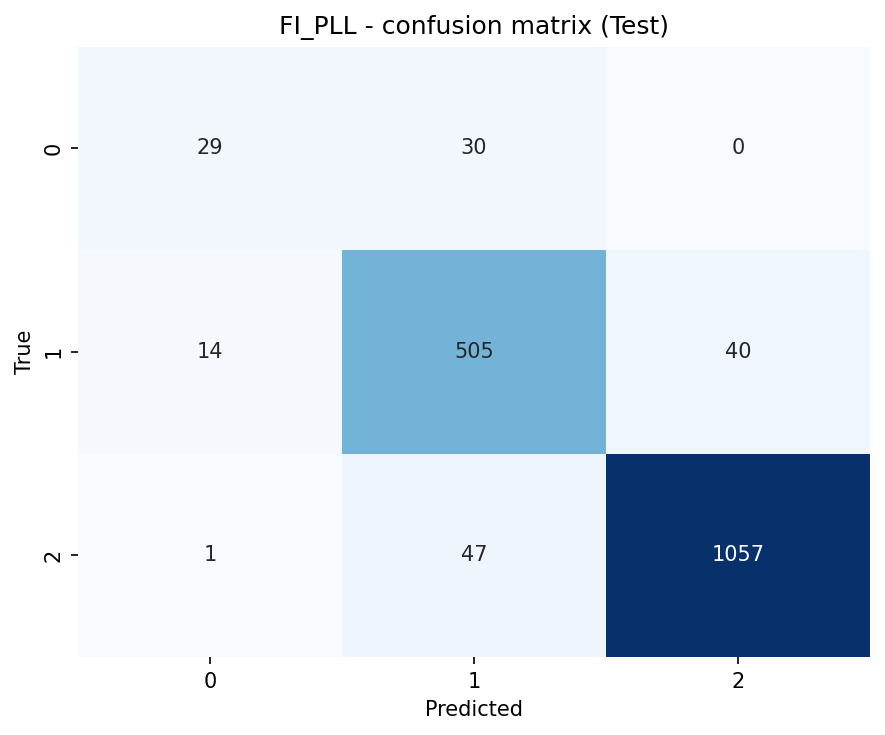


Classification Report (Test, calibrated):
              precision    recall  f1-score   support

           0     0.6591    0.4915    0.5631        59
           1     0.8677    0.9034    0.8852       559
           2     0.9635    0.9566    0.9600      1105

    accuracy                         0.9234      1723
   macro avg     0.8301    0.7838    0.8028      1723
weighted avg     0.9220    0.9234    0.9222      1723



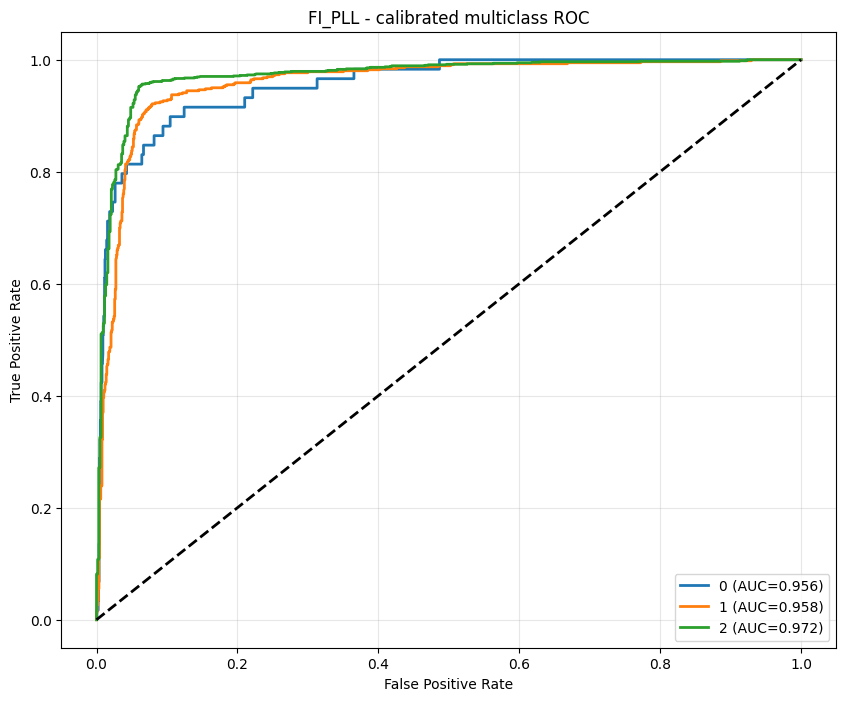

,Split,Calibration,Protocol,NLL,Objective,CDF_EMD2,Brier,ECE,Accuracy,Macro_F1,Weighted_F1,QWK,Ordinal_MAE,AUC_ROC_OVR_Macro,AUC,ChgAcc,Temperature
0,Val,raw,benchmark_ce,0.255460,0.255460,0.032609,0.127777,0.016904,0.922274,0.814988,0.921179,0.864478,0.078886,0.959780,0.959780,NaN,1.043139
1,Val,temperature_oof,benchmark_ce,0.256079,0.256079,0.032639,0.127817,0.009556,0.922274,0.814988,0.921179,0.864478,0.078886,0.958127,0.958127,NaN,1.043139
2,Test,raw,benchmark_ce,0.252653,0.252653,0.032926,0.129279,0.011140,0.923389,0.802777,0.922161,0.868484,0.077191,0.961975,0.961975,NaN,1.043139
3,Test,temperature,benchmark_ce,0.252673,0.252673,0.032909,0.129106,0.009584,0.923389,0.802777,0.922161,0.868484,0.077191,0.962025,0.962025,NaN,1.043139


Saved two-tier metrics and raw/calibrated predictions to /kaggle/working/credit_rating_artifacts


In [7]:
import time
from sklearn.metrics import roc_curve, auc

start_time = time.time()
val_fp = ens.predict_proba(val_probas)
fp = ens.predict_proba(test_probas)
temperature_result = cross_fit_temperature_scaling(
    val_fp,
    y_val,
    fp,
    max_splits=5,
    seed=42,
)
calibrated_validation_probabilities = temperature_result.validation_probabilities.astype(np.float32)
calibrated_test_probabilities = temperature_result.test_probabilities.astype(np.float32)
y_pred = np.argmax(calibrated_test_probabilities, axis=1)
elapsed_time = time.time() - start_time
print(f"Test inference/evaluation time: {elapsed_time:.6f} seconds")

metric_rows = [
    {"Split": "Val", "Calibration": "raw", **probability_report(y_val, val_fp, protocol=LOSS_PROTOCOL, ordinal_lambda=ORDINAL_LAMBDA)},
    {"Split": "Val", "Calibration": "temperature_oof", **probability_report(y_val, calibrated_validation_probabilities, protocol=LOSS_PROTOCOL, ordinal_lambda=ORDINAL_LAMBDA)},
    {"Split": "Test", "Calibration": "raw", **probability_report(y_test, fp, protocol=LOSS_PROTOCOL, ordinal_lambda=ORDINAL_LAMBDA)},
    {"Split": "Test", "Calibration": "temperature", **probability_report(y_test, calibrated_test_probabilities, protocol=LOSS_PROTOCOL, ordinal_lambda=ORDINAL_LAMBDA)},
]
mdf = pd.DataFrame(metric_rows)
mdf["Temperature"] = float(temperature_result.temperature)
val_metrics = metric_rows[1]
test_metrics = metric_rows[3]

cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
fig, ax = plt.subplots(figsize=(6, 5), dpi=150)
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
ax.set_title("FI_PLL - confusion matrix (Test)", fontweight="normal")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "fi_pll_cm.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nClassification Report (Test, calibrated):")
print(classification_report(y_test, y_pred, target_names=class_names, digits=4, zero_division=0))

plt.figure(figsize=(10, 8))
y_test_bin = label_binarize(y_test, classes=list(range(n_classes)))
for class_id in range(n_classes):
    fpr_class, tpr_class, _ = roc_curve(y_test_bin[:, class_id], calibrated_test_probabilities[:, class_id])
    roc_auc_val = auc(fpr_class, tpr_class)
    plt.plot(
        fpr_class,
        tpr_class,
        lw=2,
        label=f"{class_names[class_id]} (AUC={roc_auc_val:.3f})",
    )
plt.plot([0, 1], [0, 1], "k--", lw=2)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("FI_PLL - calibrated multiclass ROC")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.savefig(ARTIFACT_DIR / "fi_pll_roc.png", dpi=300, bbox_inches="tight")
plt.show()

mdf.to_csv(ARTIFACT_DIR / "fi_pll_metrics.csv", index=False)
np.save(ARTIFACT_DIR / "fi_pll_val_proba.npy", val_fp.astype(np.float32))
np.save(ARTIFACT_DIR / "fi_pll_test_proba.npy", fp.astype(np.float32))
np.save(ARTIFACT_DIR / "fi_pll_cal_val_proba.npy", calibrated_validation_probabilities)
np.save(ARTIFACT_DIR / "fi_pll_cal_test_proba.npy", calibrated_test_probabilities)
np.save(ARTIFACT_DIR / "fi_pll_test_pred.npy", y_pred.astype(np.int32))
display(mdf)
print("Saved two-tier metrics and raw/calibrated predictions to", ARTIFACT_DIR)


## 7. Visualize Shapley Values & Fuzzy Measure

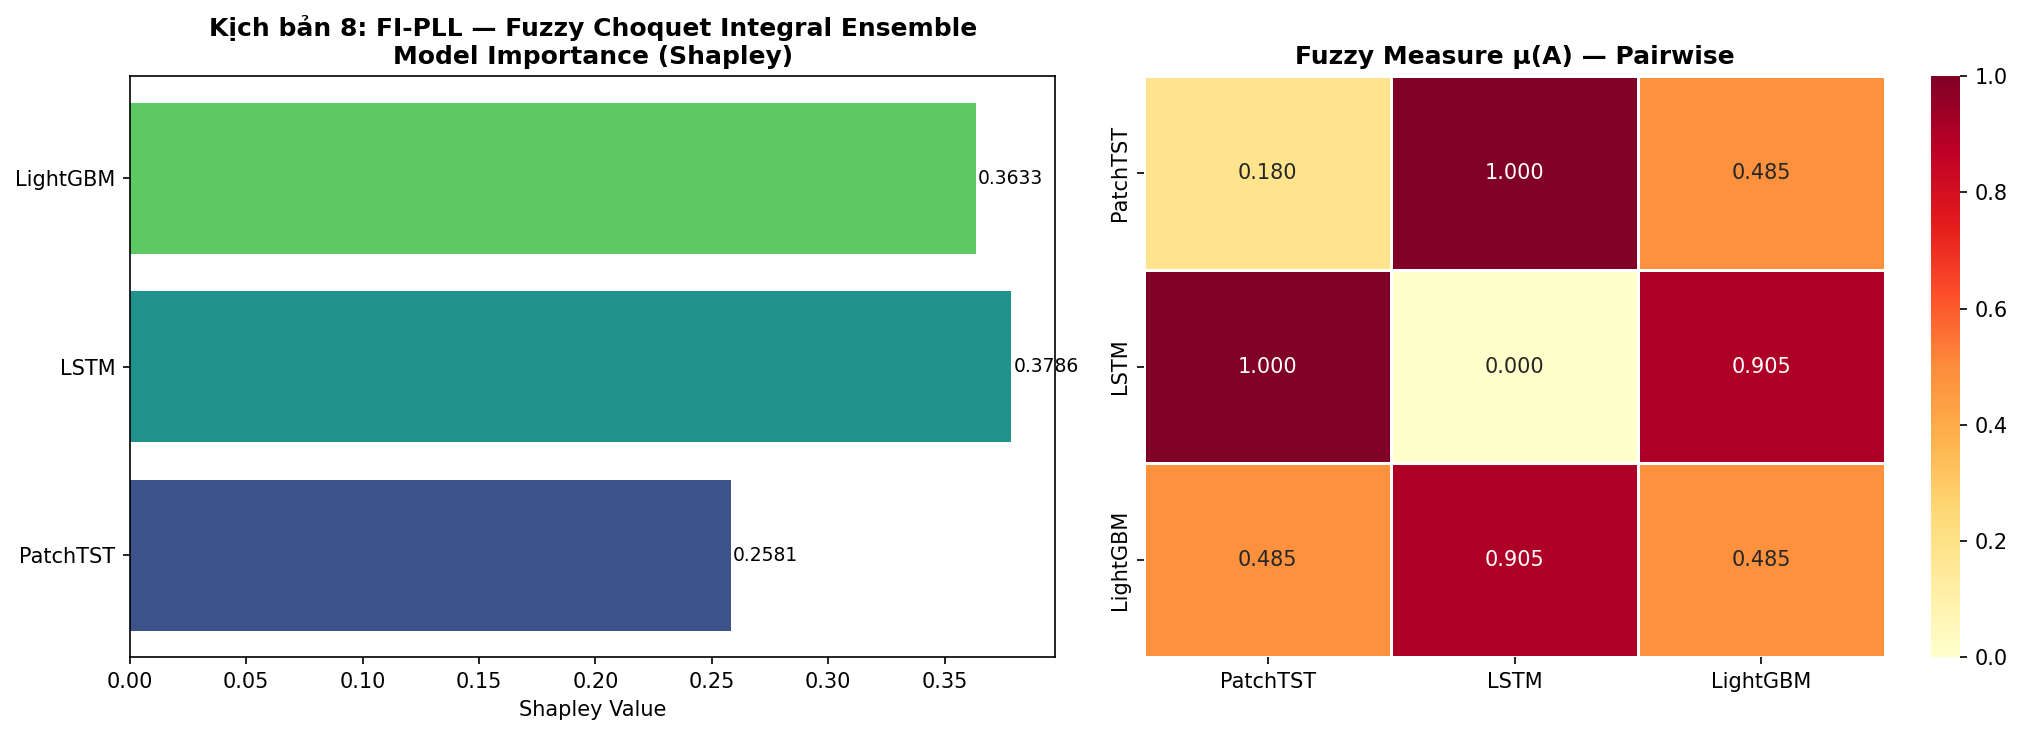

Saved: /kaggle/working/credit_rating_artifacts/fi_pll_shapley_heatmap.png


In [8]:
# ── Shapley Value Bar Chart ─────────────────────────────────────────────────
sv = ens.get_shapley()
names_sv = list(sv.keys()); vals_sv = [sv[n] for n in names_sv]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=150)

# Bar: Shapley
colors = sns.color_palette("viridis", len(names_sv))
axes[0].barh(names_sv, vals_sv, color=colors)
for i,(nm,v) in enumerate(zip(names_sv,vals_sv)):
    axes[0].text(v+0.001, i, f"{v:.4f}", va='center', fontsize=9)
axes[0].set_xlabel("Shapley Value")
axes[0].set_title('Kịch bản 8: FI-PLL — Fuzzy Choquet Integral Ensemble\nModel Importance (Shapley)', fontweight='bold')

# Heatmap: pairwise fuzzy measure
n_src = ens.n
mat = np.zeros((n_src, n_src))
for i in range(n_src):
    mat[i,i] = ens.mu.get((i,))
    for j in range(i+1, n_src):
        v = ens.mu.get((i,j))
        mat[i,j] = mat[j,i] = v

hdf = pd.DataFrame(mat, index=MODEL_NAMES, columns=MODEL_NAMES)
sns.heatmap(hdf, annot=True, fmt='.3f', cmap='YlOrRd', ax=axes[1],
            vmin=0, vmax=1, linewidths=0.5)
axes[1].set_title('Fuzzy Measure μ(A) — Pairwise', fontweight='bold')

plt.tight_layout()
plt.savefig(ARTIFACT_DIR/'fi_pll_shapley_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved:", ARTIFACT_DIR/'fi_pll_shapley_heatmap.png')


## xAI Captum GradientSHAP + LIME Interpretation

Phan xAI duoc trinh bay theo huong paper-ready cho bai toan xep hang tin dung doanh nghiep:

1. **Global Captum GradientSHAP drivers**: cac feature tai chinh/delta nao anh huong lon nhat tren tap test.
2. **Local "Why this class?"**: voi tung doanh nghiep mau, tach feature dang ung ho va chong lai lop duoc giai thich.
3. **Per-class explanation**: giai thich tung lop rating, khong chi lop argmax, de so sanh cac lop gan nhau theo ordinal risk.
4. **LIME local consistency**: LIME dung cung view feature tai chinh voi SHAP, nhung probability mac dinh lay truc tiep tu model/fusion output cua notebook.
5. **Temporal/fusion context**: baseline neural uu tien financial sequence view; ensemble/DMF giai thich tren probability inputs vi day la input that cua tang ket hop.

Luu y: GradientSHAP/LIME giai thich hanh vi cua model, khong duoc dien giai nhu quan he nhan qua tai chinh.


In [ ]:
# ============================================================
# xAI Captum GradientSHAP + LIME aligned with Transformer-LSTM presentation
# Main artifacts:
#   {model_key}_financial_shap_importance_by_class.csv
#   {model_key}_financial_shap_global_importance.csv
#   {model_key}_financial_shap_local_decisions.csv
#   {model_key}_financial_lime_local_decisions.csv
# ============================================================
SHAP_FINANCIAL_ENABLED = True
LIME_FINANCIAL_ENABLED = True
XAI_MODEL_KEY = "fi_pll"
XAI_MODEL_LABEL = "FI-PLL Fuzzy Choquet Ensemble"
XAI_RANDOM_STATE = SEED if "SEED" in globals() else 42
XAI_LOCAL_SAMPLE_COUNT = 1
XAI_LOCAL_TOP_FEATURES = 10
XAI_FINANCIAL_REDUCER = "mean"  # {"mean", "last"}; used when reducing sequence windows.
XAI_EXPLAIN_CLASS_IDS = None  # None = explain all classes; set e.g. [0, 2] to focus.
XAI_ROW_IDS = None  # Optional explicit row_id override; formats differ across model families.
XAI_SHARED_ROW_ID = "000518"  # Canonical zero-padded row in data/processed/test.csv.
XAI_SHARED_SAMPLE = {"ticker": "KOS", "company_name": "Kosmos Energy, Ltd.", "rating_date": "2016-02-09"}
XAI_REQUIRE_SHARED_SAMPLE = True  # Never silently explain a different company/date.
XAI_BACKGROUND_SIZE = 80
SHAP_MAX_SAMPLES = 12
GRADIENT_SHAP_N_SAMPLES = 64
GRADIENT_SHAP_STDEV = 0.05
XAI_PROXY_MAX_ROWS = 2500
XAI_PROXY_EPOCHS = 220
LIME_NUM_SAMPLES = 600
LIME_USE_DIRECT_MODEL_PROBA = True
XAI_BEESWARM_TOP_FEATURES = 15
XAI_LIME_PLOT_TOP_RULES = 15
XAI_LIME_INSTANCE_TOP_RULES = 8

import math
import sys
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import torch
    import torch.nn as nn
except Exception as exc:
    raise RuntimeError("xAI GradientSHAP requires PyTorch for the differentiable attribution head.") from exc


def _xai_artifact_dir():
    path = globals().get("ARTIFACT_DIR", globals().get("DMF_ARTIFACT_DIR", None))
    if path is None:
        path = Path("/kaggle/working/credit_rating_artifacts") if globals().get("IN_KAGGLE", False) else Path("credit_rating_artifacts")
    path = Path(path)
    path.mkdir(parents=True, exist_ok=True)
    return path


def _xai_normalize_proba(pred):
    pred = np.asarray(pred, dtype=np.float64)
    if pred.ndim == 1:
        pred = pred.reshape(1, -1)
    pred = np.clip(pred, 1e-9, 1.0)
    return pred / pred.sum(axis=1, keepdims=True)


def _xai_class_names(n_cls):
    if "class_names" in globals() and len(class_names) > 0:
        names = [str(x) for x in class_names]
        return names[:n_cls] if len(names) >= n_cls else names + [str(i) for i in range(len(names), n_cls)]
    if "id_to_name" in globals():
        return [str(id_to_name.get(i, i)) for i in range(n_cls)]
    if "id_to_raw" in globals():
        return [str(id_to_raw.get(i, i)) for i in range(n_cls)]
    if "raw_to_id" in globals():
        inv = {int(v): k for k, v in raw_to_id.items()}
        return [str(inv.get(i, i)) for i in range(n_cls)]
    if "le" in globals() and hasattr(le, "classes_"):
        names = [str(x) for x in le.classes_]
        return names[:n_cls] if len(names) >= n_cls else names + [str(i) for i in range(len(names), n_cls)]
    return [str(i) for i in range(n_cls)]


def _xai_resolve_class_ids(class_ids, n_cls):
    if class_ids is None:
        return list(range(n_cls))
    out = []
    for class_id in class_ids:
        class_id = int(class_id)
        if class_id < 0 or class_id >= n_cls:
            raise ValueError(f"Invalid xAI class id {class_id}; expected 0..{n_cls - 1}.")
        if class_id not in out:
            out.append(class_id)
    if not out:
        raise ValueError("XAI_EXPLAIN_CLASS_IDS resolved to an empty class list.")
    return out


def _xai_prob_columns(frame, prefix=None):
    if prefix is None:
        cols = [c for c in frame.columns if str(c).startswith("prob_")]
    else:
        cols = [c for c in frame.columns if str(c).startswith(f"{prefix}_prob_")]

    def suffix_num(name):
        try:
            return int(str(name).split("_")[-1])
        except Exception:
            return 10**9
    return sorted(cols, key=suffix_num)


def _xai_get_proba():
    for name in ["dmf_probs", "fp", "test_proba", "test_probs", "weighted_probs", "soft_probs", "y_test_proba"]:
        if name in globals():
            arr = np.asarray(globals()[name])
            if arr.ndim == 2 and arr.shape[0] > 0:
                return _xai_normalize_proba(arr), name
    if "model" in globals() and "X_test" in globals() and hasattr(model, "predict_proba"):
        X_arr = X_test.values if isinstance(X_test, pd.DataFrame) else np.asarray(X_test)
        return _xai_normalize_proba(model.predict_proba(X_arr)), "model.predict_proba(X_test)"
    for frame_name in ["test_predictions", "test_results", "test_result_df", "test_results_df", "out"]:
        if frame_name in globals() and isinstance(globals()[frame_name], pd.DataFrame):
            frame = globals()[frame_name]
            cols = _xai_prob_columns(frame)
            if cols:
                return _xai_normalize_proba(frame[cols].to_numpy(dtype=float)), frame_name
    raise RuntimeError("Kh?ng t?m th?y probability matrix cho xAI. H?y ch?y cell inference/evaluation tr??c.")



_XAI_CANONICAL_FINANCIAL_FEATURES = [
    "current_ratio",
    "debt_equity_ratio",
    "gross_profit_margin",
    "operating_profit_margin",
    "ebit_margin",
    "pretax_profit_margin",
    "net_profit_margin",
    "asset_turnover",
    "roe",
    "roa",
    "operating_cashflow_ps",
    "free_cashflow_ps",
]
_XAI_NON_FINANCIAL_EXACT = {
    "row_id", "test_index", "split", "ticker", "company_name", "rating_agency", "rating_date",
    "sector", "source", "rating_detail", "true_label", "true_label_name", "pred_label",
    "pred_label_name", "prediction", "confidence", "selected_model", "dcs_case", "delta_days",
}
_XAI_NON_FINANCIAL_TOKENS = (
    "prob_", "_prob_", "pred_", "_pred_", "confidence", "weight", "score", "delta",
    "k_eff", "reference_count", "case", "model", "label", "class", "rank", "index",
)
_xai_financial_frame_cache = None
_xai_financial_frame_cache_rows = None


def _xai_financial_feature_columns(frame):
    if not isinstance(frame, pd.DataFrame) or frame.empty:
        return []
    explicit = []
    for source_name in ["FINANCIAL_FEATURES", "MODEL_FEATURES", "feature_cols", "financial_cols"]:
        values = globals().get(source_name, [])
        if isinstance(values, (list, tuple, pd.Index)):
            explicit.extend([c for c in values if c in frame.columns])
    if explicit:
        return list(dict.fromkeys(explicit))

    canonical = [c for c in _XAI_CANONICAL_FINANCIAL_FEATURES if c in frame.columns]
    if canonical:
        return canonical

    inferred = []
    for col in frame.columns:
        name = str(col)
        low = name.lower()
        if low in _XAI_NON_FINANCIAL_EXACT:
            continue
        if low.startswith("prob_") or any(token in low for token in _XAI_NON_FINANCIAL_TOKENS):
            continue
        try:
            if pd.api.types.is_numeric_dtype(frame[col]):
                inferred.append(col)
        except Exception:
            continue
    return inferred


def _xai_load_split_test_frame():
    candidates = []
    if "TEST_PATH" in globals():
        candidates.append(Path(globals()["TEST_PATH"]))
    if "PROJECT_ROOT" in globals():
        root = Path(globals()["PROJECT_ROOT"])
        candidates.extend([
            root / "data" / "processed" / "test" / "test.csv",
            root / "data" / "processed" / "test.csv",
        ])
    candidates.extend([
        Path("/kaggle/input/datasets/tailength/corporate-credit-rating/test/test.csv"),
        Path("data/processed/test/test.csv"),
        Path("data/processed/test/test.csv"),
    ])
    seen = set()
    for path in candidates:
        path = Path(path)
        key = str(path)
        if key in seen:
            continue
        seen.add(key)
        if path.exists():
            try:
                return pd.read_csv(path, encoding="utf-8")
            except UnicodeDecodeError:
                return pd.read_csv(path, encoding="utf-8-sig")
            except Exception as exc:
                print(f"[WARN] Khong doc duoc split test cho xAI tai {path}: {exc}")
    return None


def _xai_frame_has_financials(frame):
    return isinstance(frame, pd.DataFrame) and bool(_xai_financial_feature_columns(frame))


def _xai_reconstruct_index_aligned_test_frame(n_rows):
    if "_y_test_path" not in globals():
        return None
    try:
        y_index_path = Path(globals()["_y_test_path"])
    except Exception:
        return None
    if not y_index_path.exists():
        return None
    try:
        raw_index = np.load(str(y_index_path), allow_pickle=True)
    except Exception:
        return None
    raw_index = np.asarray(raw_index)
    if raw_index.ndim != 1 or len(raw_index) < n_rows:
        return None
    numeric_index = pd.to_numeric(pd.Series(raw_index[:n_rows]), errors="coerce")
    if numeric_index.isna().any():
        return None
    class_count = int(globals().get("n_classes", len(globals().get("class_names", [])) or 0))
    if class_count > 0 and int(numeric_index.max()) < class_count:
        return None
    if not all(name in globals() and isinstance(globals()[name], pd.DataFrame) for name in ["df_train", "df_val", "df_test"]):
        return None
    pieces = [globals()[name] for name in ["df_train", "df_val", "df_test"]]
    target_col = globals().get("TARGET_COL", "rating_detail")
    frame_full = pd.concat(pieces, ignore_index=True)
    if target_col in frame_full.columns:
        frame_full = frame_full.dropna(subset=[target_col]).reset_index(drop=True)
    idx = numeric_index.astype(int).to_numpy()
    if idx.max(initial=-1) >= len(frame_full):
        return None
    aligned = frame_full.iloc[idx].reset_index(drop=True)
    return aligned if _xai_frame_has_financials(aligned) else None


def _xai_merge_financial_split(base_frame, raw_frame, n_rows):
    if not isinstance(base_frame, pd.DataFrame) or not isinstance(raw_frame, pd.DataFrame):
        return None
    if len(base_frame) < n_rows:
        return None
    base = base_frame.reset_index(drop=True).loc[:n_rows - 1].copy()
    raw = raw_frame.reset_index(drop=True).copy()

    if "row_id" in base.columns and "row_id" in raw.columns:
        left = base.copy()
        right = raw.copy()
        left["_xai_row_key"] = left["row_id"].astype(str)
        right["_xai_row_key"] = right["row_id"].astype(str)
        merged = left.merge(right, on="_xai_row_key", how="left", suffixes=("", "_financial"), sort=False)
        if len(merged) == len(base) and _xai_frame_has_financials(merged):
            return merged

    keys = [c for c in ["ticker", "rating_date", "company_name"] if c in base.columns and c in raw.columns]
    if len(keys) >= 2:
        merged = base.merge(raw, on=keys, how="left", suffixes=("", "_financial"), sort=False)
        if len(merged) == len(base) and _xai_frame_has_financials(merged):
            return merged

    if len(raw) >= n_rows and _xai_frame_has_financials(raw):
        print("[WARN] xAI dung thu tu split test de can hang dac trung tai chinh vi khong co khoa merge tuyet doi.")
        return raw.loc[:n_rows - 1].reset_index(drop=True)
    return None


def _xai_aligned_financial_frame(n_rows):
    global _xai_financial_frame_cache, _xai_financial_frame_cache_rows
    if _xai_financial_frame_cache is not None and _xai_financial_frame_cache_rows == n_rows:
        return _xai_financial_frame_cache

    aligned = _xai_reconstruct_index_aligned_test_frame(n_rows)
    if aligned is not None:
        _xai_financial_frame_cache = aligned.reset_index(drop=True).loc[:n_rows - 1].copy()
        _xai_financial_frame_cache_rows = n_rows
        return _xai_financial_frame_cache

    for frame_name in ["df_test", "test_financial_df", "test_rows", "test_df", "out"]:
        frame = globals().get(frame_name)
        if isinstance(frame, pd.DataFrame) and len(frame) >= n_rows and _xai_frame_has_financials(frame):
            if frame_name == "df_test" and "test_probas" in globals():
                print("[WARN] xAI dung df_test de giai thich dac trung tai chinh; hay dam bao thu tu df_test khop artifact du doan.")
            _xai_financial_frame_cache = frame.reset_index(drop=True).loc[:n_rows - 1].copy()
            _xai_financial_frame_cache_rows = n_rows
            return _xai_financial_frame_cache

    raw_test = _xai_load_split_test_frame()
    if raw_test is not None:
        for frame_name in ["test_df", "out", "test_predictions", "test_results_df"]:
            merged = _xai_merge_financial_split(globals().get(frame_name), raw_test, n_rows)
            if merged is not None:
                _xai_financial_frame_cache = merged.reset_index(drop=True).loc[:n_rows - 1].copy()
                _xai_financial_frame_cache_rows = n_rows
                return _xai_financial_frame_cache
        if len(raw_test) >= n_rows and _xai_frame_has_financials(raw_test):
            print("[WARN] xAI dung split test theo thu tu hang de giai thich dac trung tai chinh.")
            _xai_financial_frame_cache = raw_test.reset_index(drop=True).loc[:n_rows - 1].copy()
            _xai_financial_frame_cache_rows = n_rows
            return _xai_financial_frame_cache

    return None

def _xai_get_feature_view(proba):
    aligned_financial = _xai_aligned_financial_frame(len(proba))
    if aligned_financial is not None:
        financial_cols = _xai_financial_feature_columns(aligned_financial)
        if financial_cols:
            return aligned_financial[financial_cols].to_numpy(dtype=np.float64), [str(c) for c in financial_cols], "aligned_financial_features"
    if "test_ds" in globals() and hasattr(test_ds, "samples") and len(test_ds.samples) > 0:
        seq = np.stack([s[0] for s in test_ds.samples], axis=0).astype(np.float64)
        feature_cols = [str(c) for c in globals().get("MODEL_FEATURES", globals().get("FINANCIAL_FEATURES", [f"feature_{i}" for i in range(seq.shape[-1])]))]
        return seq.mean(axis=1), feature_cols, "financial_sequence_mean"
    if "test_X_all" in globals():
        arr = np.asarray(test_X_all, dtype=np.float64)
        if arr.ndim == 3:
            feature_cols = [str(c) for c in globals().get("MODEL_FEATURES", globals().get("FINANCIAL_FEATURES", [f"feature_{i}" for i in range(arr.shape[-1])]))]
            return arr.mean(axis=1), feature_cols, "financial_sequence_mean"
        if arr.ndim == 2:
            feature_cols = [str(c) for c in globals().get("flat_feature_names", [f"feature_{i}" for i in range(arr.shape[1])])]
            return arr, feature_cols, "flattened_sequence"
    if "X_test" in globals():
        arr = X_test.values if isinstance(X_test, pd.DataFrame) else np.asarray(X_test)
        arr = np.asarray(arr, dtype=np.float64)
        if "MODEL_FEATURES" in globals() and "INPUT_SIZE" in globals() and arr.ndim == 2 and arr.shape[1] >= int(INPUT_SIZE) * len(MODEL_FEATURES):
            n_base = len(MODEL_FEATURES)
            window = arr[:, :int(INPUT_SIZE) * n_base].reshape(arr.shape[0], int(INPUT_SIZE), n_base)
            return window.mean(axis=1), [str(c) for c in MODEL_FEATURES], "financial_tabular_window_mean"
        cols = list(X_test.columns) if isinstance(X_test, pd.DataFrame) else [f"feature_{i}" for i in range(arr.shape[1])]
        return arr, [str(c) for c in cols], "tabular_features"
    if "df" in globals() and "test_mask" in globals():
        mask = test_mask.detach().cpu().numpy() if hasattr(test_mask, "detach") else np.asarray(test_mask)
        frame = df.loc[mask].reset_index(drop=True)
        financial_cols = _xai_financial_feature_columns(frame)
        if financial_cols:
            return frame[financial_cols].to_numpy(dtype=np.float64), [str(c) for c in financial_cols], "df_test_mask_financial_features"
    for frame_name in ["test_df", "df_test", "test_rows", "out"]:
        if frame_name in globals() and isinstance(globals()[frame_name], pd.DataFrame):
            frame = globals()[frame_name]
            financial_cols = _xai_financial_feature_columns(frame)
            if financial_cols:
                return frame[financial_cols].to_numpy(dtype=np.float64), [str(c) for c in financial_cols], f"{frame_name}_financial_features"
            prob_cols = []
            for prefix in ["tlstm", "gat", "lstm", "tcn", "patchtst", "xgboost", "lightgbm", "dmf"]:
                prob_cols.extend(_xai_prob_columns(frame, prefix=prefix))
            if prob_cols:
                return frame[prob_cols].to_numpy(dtype=np.float64), [str(c) for c in prob_cols], f"{frame_name}_probability_inputs"
    if "test_probas" in globals() and isinstance(test_probas, list) and len(test_probas) > 0:
        mats = [np.asarray(p, dtype=np.float64) for p in test_probas]
        if all(m.ndim == 2 for m in mats):
            names = globals().get("MODEL_NAMES", [f"model_{i}" for i in range(len(mats))])
            feature_cols = []
            for model_name, mat in zip(names, mats):
                for class_idx in range(mat.shape[1]):
                    feature_cols.append(f"{model_name}_prob_{class_idx}")
            return np.concatenate(mats, axis=1), feature_cols, "ensemble_probability_inputs"
    return np.asarray(proba, dtype=np.float64), [f"predicted_prob_{i}" for i in range(proba.shape[1])], "model_probability_vector"


def _xai_metadata(n_rows):
    meta_cols = ["row_id", "ticker", "company_name", "rating_date", "sector", "true_label", "true_label_name"]
    aligned_financial = globals().get("_xai_financial_frame_cache", None)
    if isinstance(aligned_financial, pd.DataFrame) and len(aligned_financial) >= n_rows:
        cols = [c for c in meta_cols if c in aligned_financial.columns]
        if cols:
            return aligned_financial.reset_index(drop=True).loc[:n_rows - 1, cols].copy()
    for frame_name in ["test_df", "df_test", "test_rows", "out", "test_predictions", "test_results_df"]:
        if frame_name in globals() and isinstance(globals()[frame_name], pd.DataFrame) and len(globals()[frame_name]) >= n_rows:
            frame = globals()[frame_name].reset_index(drop=True)
            cols = [c for c in meta_cols if c in frame.columns]
            if cols:
                return frame.loc[:n_rows - 1, cols].copy()
    if "df" in globals() and "test_mask" in globals():
        mask = test_mask.detach().cpu().numpy() if hasattr(test_mask, "detach") else np.asarray(test_mask)
        frame = df.loc[mask].reset_index(drop=True)
        cols = [c for c in meta_cols if c in frame.columns]
        if cols and len(frame) >= n_rows:
            return frame.loc[:n_rows - 1, cols].copy()
    meta = pd.DataFrame({"test_index": np.arange(n_rows, dtype=int)})
    if "y_test" in globals() and len(y_test) >= n_rows:
        meta["true_label"] = np.asarray(y_test[:n_rows], dtype=int)
    elif "y_true" in globals() and len(y_true) >= n_rows:
        meta["true_label"] = np.asarray(y_true[:n_rows], dtype=int)
    return meta


def _xai_shared_sample_id():
    ticker = str(XAI_SHARED_SAMPLE.get("ticker", "")).strip().upper()
    rating_date = pd.to_datetime(XAI_SHARED_SAMPLE.get("rating_date", ""), errors="coerce")
    date_key = rating_date.strftime("%Y-%m-%d") if not pd.isna(rating_date) else str(XAI_SHARED_SAMPLE.get("rating_date", "")).strip()
    sample_key = f"{ticker}|{date_key}"
    if sample_key != "KOS|2016-02-09":
        raise ValueError(f"XAI_SHARED_ROW_ID={XAI_SHARED_ROW_ID} no longer maps to the expected sample: {sample_key}.")
    return str(XAI_SHARED_ROW_ID).zfill(6)


def _xai_shared_sample_mask(meta):
    mask = np.ones(len(meta), dtype=bool)
    required = [key for key, value in XAI_SHARED_SAMPLE.items() if str(value).strip()]
    missing = [key for key in required if key not in meta.columns]
    if missing:
        if XAI_REQUIRE_SHARED_SAMPLE:
            raise KeyError(f"Cannot resolve shared xAI sample {_xai_shared_sample_id()}: missing metadata columns {missing}.")
        return np.zeros(len(meta), dtype=bool)
    for key in required:
        expected = XAI_SHARED_SAMPLE[key]
        if key == "rating_date":
            parsed_values = meta[key].map(lambda value: pd.to_datetime(value, errors="coerce"))
            values = parsed_values.map(lambda value: value.strftime("%Y-%m-%d") if not pd.isna(value) else "")
            expected_date = pd.to_datetime(expected, errors="coerce")
            expected_key = expected_date.strftime("%Y-%m-%d") if not pd.isna(expected_date) else str(expected).strip()
            mask &= values.fillna(meta[key].astype(str).str.strip()).eq(expected_key).to_numpy()
        else:
            values = meta[key].fillna("").astype(str).str.strip().str.casefold()
            mask &= values.eq(str(expected).strip().casefold()).to_numpy()
    return mask


def _xai_select_indices(meta, proba):
    n_rows = len(meta)
    if XAI_ROW_IDS is not None:
        if "row_id" not in meta.columns:
            if XAI_REQUIRE_SHARED_SAMPLE:
                raise KeyError("XAI_ROW_IDS was set, but xAI metadata has no row_id column.")
        else:
            wanted = {str(x) for x in XAI_ROW_IDS}
            idx = [int(i) for i, row_id in enumerate(meta["row_id"].astype(str)) if row_id in wanted]
            if idx:
                return idx[:XAI_LOCAL_SAMPLE_COUNT]
            if XAI_REQUIRE_SHARED_SAMPLE:
                raise ValueError(f"Requested XAI_ROW_IDS={sorted(wanted)} are absent from this notebook test metadata.")
    shared_idx = np.flatnonzero(_xai_shared_sample_mask(meta)).astype(int).tolist()
    if len(shared_idx) == 1:
        return shared_idx
    if len(shared_idx) > 1:
        raise ValueError(f"Shared xAI sample {_xai_shared_sample_id()} is ambiguous: matched indices={shared_idx[:10]}.")
    if XAI_REQUIRE_SHARED_SAMPLE:
        raise ValueError(f"Shared xAI sample {_xai_shared_sample_id()} was not found in this notebook test metadata.")
    confidence = proba.max(axis=1)
    ranked = np.argsort(-confidence)
    selected = []
    preds = proba.argmax(axis=1)
    for class_id in np.unique(preds[ranked]):
        class_ranked = [int(i) for i in ranked if preds[i] == class_id]
        if class_ranked:
            selected.append(class_ranked[0])
        if len(selected) >= XAI_LOCAL_SAMPLE_COUNT:
            break
    for i in ranked:
        i = int(i)
        if i not in selected:
            selected.append(i)
        if len(selected) >= XAI_LOCAL_SAMPLE_COUNT:
            break
    return selected


class _XAIProbabilityHead(nn.Module):
    def __init__(self, n_features, n_classes):
        super().__init__()
        hidden = int(min(96, max(16, 2 * n_features)))
        self.net = nn.Sequential(
            nn.Linear(n_features, hidden),
            nn.ReLU(),
            nn.Linear(hidden, n_classes),
        )

    def forward(self, x):
        return torch.softmax(self.net(x.float()), dim=1)


def _xai_train_probability_head(X_view, proba):
    rng = np.random.default_rng(XAI_RANDOM_STATE)
    X_view = np.asarray(X_view, dtype=np.float64)
    proba = _xai_normalize_proba(proba)
    center = np.nanmedian(X_view, axis=0)
    scale = np.nanstd(X_view, axis=0)
    scale = np.where(scale < 1e-8, 1.0, scale)
    X_std = np.nan_to_num((X_view - center) / scale, nan=0.0, posinf=0.0, neginf=0.0)
    n_rows = len(X_std)
    fit_idx = np.arange(n_rows)
    if n_rows > XAI_PROXY_MAX_ROWS:
        fit_idx = rng.choice(n_rows, size=XAI_PROXY_MAX_ROWS, replace=False)
    device_xai = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    head = _XAIProbabilityHead(X_std.shape[1], proba.shape[1]).to(device_xai)
    x_train = torch.tensor(X_std[fit_idx], dtype=torch.float32, device=device_xai)
    y_train = torch.tensor(proba[fit_idx], dtype=torch.float32, device=device_xai)
    opt = torch.optim.AdamW(head.parameters(), lr=0.01, weight_decay=1e-4)
    head.train()
    for _ in range(int(XAI_PROXY_EPOCHS)):
        opt.zero_grad(set_to_none=True)
        pred = head(x_train)
        loss = torch.mean((pred - y_train) ** 2)
        loss.backward()
        opt.step()
    head.eval()
    with torch.no_grad():
        pred_all = head(torch.tensor(X_std, dtype=torch.float32, device=device_xai)).detach().cpu().numpy()
    fidelity = {
        "proxy_mse": float(np.mean((pred_all - proba) ** 2)),
        "proxy_argmax_agreement": float(np.mean(pred_all.argmax(axis=1) == proba.argmax(axis=1))),
    }
    return head, X_std.astype(np.float32), center, scale, device_xai, fidelity


def _xai_predict_from_head(head, center, scale, device_xai, x_batch):
    x_batch = np.asarray(x_batch, dtype=np.float64)
    if x_batch.ndim == 1:
        x_batch = x_batch.reshape(1, -1)
    x_std = np.nan_to_num((x_batch - center) / scale, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
    with torch.no_grad():
        pred = head(torch.tensor(x_std, dtype=torch.float32, device=device_xai)).detach().cpu().numpy()
    return _xai_normalize_proba(pred)


def _xai_gradientshap_attributions(head, X_std, sample_indices, background_indices, class_ids, device_xai):
    x_samples = torch.tensor(X_std[sample_indices], dtype=torch.float32, device=device_xai)
    baselines = torch.tensor(X_std[background_indices], dtype=torch.float32, device=device_xai)
    method = "captum_gradientshap_probability_head"
    attributions = {}
    try:
        from captum.attr import GradientShap
        gs = GradientShap(head)
        for class_id in class_ids:
            attr = gs.attribute(
                x_samples,
                baselines=baselines,
                target=int(class_id),
                n_samples=int(GRADIENT_SHAP_N_SAMPLES),
                stdevs=float(GRADIENT_SHAP_STDEV),
            )
            attributions[int(class_id)] = attr.detach().cpu().numpy()
    except Exception as exc:
        method = f"expected_gradients_fallback: {type(exc).__name__}"
        rng = np.random.default_rng(XAI_RANDOM_STATE)
        for class_id in class_ids:
            rows = []
            for x_np in X_std[sample_indices]:
                accum = []
                for _ in range(int(GRADIENT_SHAP_N_SAMPLES)):
                    b_np = X_std[int(rng.choice(background_indices))]
                    alpha = float(rng.uniform(0.0, 1.0))
                    noise = rng.normal(0.0, float(GRADIENT_SHAP_STDEV), size=x_np.shape).astype(np.float32)
                    interp_np = b_np + alpha * (x_np - b_np) + noise
                    interp = torch.tensor(interp_np.reshape(1, -1), dtype=torch.float32, device=device_xai, requires_grad=True)
                    score = head(interp)[:, int(class_id)].sum()
                    grad = torch.autograd.grad(score, interp)[0].detach().cpu().numpy()[0]
                    accum.append((x_np - b_np) * grad)
                rows.append(np.mean(accum, axis=0))
            attributions[int(class_id)] = np.asarray(rows, dtype=np.float32)
    return attributions, method


def _xai_lime_fallback(x_row, predict_fn, class_id, feature_names, num_features):
    rng = np.random.default_rng(XAI_RANDOM_STATE + int(class_id))
    x_row = np.asarray(x_row, dtype=np.float64)
    perturb = rng.normal(loc=x_row, scale=np.maximum(np.nanstd(x_row), 1e-3), size=(int(LIME_NUM_SAMPLES), len(x_row)))
    perturb[0] = x_row
    probs = _xai_normalize_proba(predict_fn(perturb))[:, int(class_id)]
    distances = np.linalg.norm(perturb - x_row.reshape(1, -1), axis=1)
    kernel_width = math.sqrt(len(x_row)) * 0.75
    weights = np.exp(-(distances ** 2) / max(kernel_width ** 2, 1e-9))
    X_aug = np.column_stack([np.ones(len(perturb)), perturb - x_row.reshape(1, -1)])
    W = np.sqrt(weights).reshape(-1, 1)
    coef = np.linalg.lstsq(X_aug * W, probs * W.ravel(), rcond=None)[0][1:]
    order = np.argsort(-np.abs(coef))[:num_features]
    return [(str(feature_names[j]), float(coef[j])) for j in order]



def _xai_short_text(text, max_len=34):
    text = str(text)
    return text if len(text) <= int(max_len) else text[: max(1, int(max_len) - 3)] + "..."


def _xai_wrap_text(text, width=28, max_lines=3):
    import textwrap

    lines = textwrap.wrap(str(text), width=int(width), break_long_words=False, replace_whitespace=False)
    if not lines:
        return ""
    if len(lines) > int(max_lines):
        lines = lines[: int(max_lines)]
        lines[-1] = _xai_short_text(lines[-1], max(4, int(width) - 1))
    return "\n".join(lines)


def _xai_lime_rule_feature(rule, feature_names):
    rule_text = str(rule)
    for feature in sorted([str(f) for f in feature_names], key=len, reverse=True):
        if feature in rule_text:
            return feature
    return rule_text

def _xai_save_lime_multiclass_instance_plot(row_meta, exp, model_proba, lime_proba, x_row, html_path, lime_available):
    from matplotlib.patches import Rectangle

    row_id = str(row_meta.get("row_id", row_meta.get("test_index", "unknown")))
    safe_row_id = "".join(ch if ch.isalnum() or ch in ("-", "_") else "_" for ch in row_id)
    class_ids = list(explain_class_ids)
    if lime_available and exp is not None:
        class_items = {
            int(class_id): exp.as_list(label=int(class_id))[: min(int(XAI_LIME_INSTANCE_TOP_RULES), int(XAI_LOCAL_TOP_FEATURES))]
            for class_id in class_ids
        }
    else:
        class_items = {
            int(class_id): _xai_lime_fallback(x_row, _xai_probability_fn, int(class_id), feature_cols, min(int(XAI_LIME_INSTANCE_TOP_RULES), int(XAI_LOCAL_TOP_FEATURES)))
            for class_id in class_ids
        }
    if not any(class_items.values()):
        return None

    support_color = "#ff7f0e"
    oppose_color = "#5f9ea0"
    pred_class = int(np.argmax(model_proba))
    all_weights = [abs(float(weight)) for items in class_items.values() for _, weight in items]
    common_max_abs = max(max(all_weights, default=1e-3), 1e-3)

    max_items = max(len(items) for items in class_items.values())
    fig_height = max(9.6, 1.18 * max_items + 4.2)
    fig_width = max(24.0, 10.5 + 6.6 * len(class_ids))
    fig = plt.figure(figsize=(fig_width, fig_height), constrained_layout=False)
    gs = fig.add_gridspec(1, 2 + len(class_ids), width_ratios=[1.75] + [3.35] * len(class_ids) + [2.65], wspace=0.90)

    ax_prob = fig.add_subplot(gs[0, 0])
    prob_y = np.arange(len(class_names_xai))
    prob_colors = [support_color if i == pred_class else "white" for i in range(len(class_names_xai))]
    ax_prob.barh(prob_y, lime_proba, color=prob_colors, edgecolor="black", height=0.72)
    ax_prob.set_yticks(prob_y)
    ax_prob.set_yticklabels([_xai_wrap_text(name, 16, 2) for name in class_names_xai], fontsize=12)
    ax_prob.set_xlim(0, 1.0)
    ax_prob.set_xticks([])
    ax_prob.set_title("Prediction probabilities", fontsize=16, loc="left")
    for y, value in zip(prob_y, lime_proba):
        ax_prob.text(min(float(value) + 0.03, 0.98), y, f"{float(value):.2f}", va="center", fontsize=12)
    for spine in ax_prob.spines.values():
        spine.set_visible(False)
    ax_prob.tick_params(axis="y", length=0)
    ax_prob.invert_yaxis()

    for panel_idx, class_id in enumerate(class_ids, start=1):
        items = class_items[int(class_id)]
        ax_rules = fig.add_subplot(gs[0, panel_idx])
        if not items:
            ax_rules.axis("off")
            continue
        rule_labels = [_xai_wrap_text(rule, 28, 4) for rule, _ in items]
        weights = np.array([float(weight) for _, weight in items], dtype=float)
        y_pos = np.arange(len(items))
        bar_colors = [support_color if weight >= 0 else oppose_color for weight in weights]
        ax_rules.barh(y_pos, weights, color=bar_colors, height=0.68)
        ax_rules.axvline(0, color="black", linewidth=1.0)
        ax_rules.set_yticks(y_pos)
        ax_rules.set_yticklabels(rule_labels, fontsize=11.2, linespacing=1.15)
        ax_rules.set_xlim(-common_max_abs * 1.32, common_max_abs * 1.32)
        ax_rules.set_xticks([])
        title_color = support_color if int(class_id) == pred_class else oppose_color
        ax_rules.set_title(_xai_wrap_text(class_names_xai[int(class_id)], 16, 2), fontsize=15, color=title_color, pad=20)
        for y, weight in zip(y_pos, weights):
            x_text = weight + (0.025 * common_max_abs if weight >= 0 else -0.025 * common_max_abs)
            ha = "left" if weight >= 0 else "right"
            ax_rules.text(x_text, y, f"{weight:.2f}", va="center", ha=ha, fontsize=10.8)
        for spine in ax_rules.spines.values():
            spine.set_visible(False)
        ax_rules.tick_params(axis="y", length=0)
        ax_rules.invert_yaxis()

    ax_table = fig.add_subplot(gs[0, -1])
    ax_table.axis("off")
    ax_table.text(0.05, 0.98, "Feature", fontsize=15, fontweight="bold", va="top")
    ax_table.text(0.97, 0.98, "Value", fontsize=15, fontweight="bold", ha="right", va="top")
    seen_features = []
    feature_rows = []
    for _, items in class_items.items():
        for rule, weight in items:
            feat = _xai_lime_rule_feature(rule, feature_cols)
            if feat in seen_features:
                continue
            seen_features.append(feat)
            feat_value = np.nan
            if feat in feature_cols:
                feat_value = float(x_row[feature_cols.index(feat)])
            feature_rows.append((feat, feat_value, float(weight)))
            if len(feature_rows) >= int(XAI_LIME_INSTANCE_TOP_RULES):
                break
        if len(feature_rows) >= int(XAI_LIME_INSTANCE_TOP_RULES):
            break
    row_height = 0.78 / max(len(feature_rows), 1)
    for offset, (feat, feat_value, weight) in enumerate(feature_rows):
        y0 = 0.88 - (offset + 1) * row_height
        color = support_color if weight >= 0 else oppose_color
        ax_table.add_patch(Rectangle((0.02, y0), 0.96, row_height * 0.94, transform=ax_table.transAxes, facecolor=color, edgecolor="none", alpha=0.95))
        value_text = "" if not np.isfinite(feat_value) else f"{feat_value:.2f}"
        ax_table.text(0.05, y0 + row_height * 0.47, _xai_wrap_text(feat, 15, 3), transform=ax_table.transAxes, va="center", fontsize=10.8, color="white", fontweight="bold", linespacing=1.08)
        ax_table.text(0.97, y0 + row_height * 0.47, value_text, transform=ax_table.transAxes, va="center", ha="right", fontsize=11.0, color="white")

    shared_row_id = str(row_meta.get("xai_shared_row_id", XAI_SHARED_ROW_ID)).zfill(6)
    title = f"LIME row_id={shared_row_id} | model_row_id={row_id} | pred={class_names_xai[pred_class]} | all {len(class_ids)} classes"
    fig.suptitle(title, y=0.995, fontsize=15)
    fig.subplots_adjust(left=0.055, right=0.985, top=0.86, bottom=0.08)
    plot_path = _xai_artifact_dir() / f"{XAI_MODEL_KEY}_financial_lime_row_{shared_row_id}_all_classes_plot.png"
    plt.savefig(plot_path, dpi=180, bbox_inches="tight")
    plt.show()
    return plot_path


proba, proba_source = _xai_get_proba()
X_view, feature_cols, feature_source = _xai_get_feature_view(proba)
X_view = np.asarray(X_view, dtype=np.float64)
n_rows = min(len(X_view), len(proba))
X_view = X_view[:n_rows]
proba = proba[:n_rows]
class_names_xai = _xai_class_names(proba.shape[1])
explain_class_ids = _xai_resolve_class_ids(XAI_EXPLAIN_CLASS_IDS, proba.shape[1])
meta = _xai_metadata(n_rows).reset_index(drop=True)
meta["xai_shared_row_id"] = _xai_shared_sample_id()
meta["xai_shared_sample_id"] = meta["xai_shared_row_id"]
selected_indices = _xai_select_indices(meta, proba)
selected_case = meta.iloc[selected_indices][[c for c in ["xai_shared_row_id", "row_id", "ticker", "company_name", "rating_date"] if c in meta.columns]].rename(columns={"row_id": "model_row_id"}).to_dict("records")
print("[INFO] Shared LIME sample:", selected_case)
background_size = min(int(XAI_BACKGROUND_SIZE), n_rows)
rng = np.random.default_rng(XAI_RANDOM_STATE)
background_indices = rng.choice(n_rows, size=background_size, replace=False) if n_rows > background_size else np.arange(n_rows)
grad_sample_size = min(int(SHAP_MAX_SAMPLES), n_rows)
grad_sample_indices = rng.choice(n_rows, size=grad_sample_size, replace=False) if n_rows > grad_sample_size else np.arange(n_rows)

print(f"[INFO] xAI for {XAI_MODEL_LABEL}: rows={n_rows}, feature_source={feature_source}, probability_source={proba_source}")
print("[INFO] GradientSHAP and LIME use the same xAI probability function for local consistency.")
print("[INFO] Direct model probabilities are used when the notebook exposes them; otherwise a compact differentiable probability head is fitted to the notebook outputs.")
print("[INFO] Explained classes:", [class_names_xai[i] for i in explain_class_ids])

xai_head, X_std, xai_center, xai_scale, xai_device, proxy_fidelity = _xai_train_probability_head(X_view, proba)
print("[INFO] xAI probability-head fidelity:", proxy_fidelity)


def _xai_probability_fn(x_batch):
    return _xai_predict_from_head(xai_head, xai_center, xai_scale, xai_device, x_batch)

if SHAP_FINANCIAL_ENABLED:
    attrs_by_class, gradientshap_method = _xai_gradientshap_attributions(
        xai_head, X_std, grad_sample_indices, background_indices, explain_class_ids, xai_device
    )
    global_rows = []
    for class_id, attrs in attrs_by_class.items():
        mean_abs = np.mean(np.abs(attrs), axis=0)
        signed = np.mean(attrs, axis=0)
        for rank, j in enumerate(np.argsort(-mean_abs), start=1):
            global_rows.append({
                "rank": int(rank), "model_key": XAI_MODEL_KEY, "model_label": XAI_MODEL_LABEL,
                "class_id": int(class_id), "class_name": class_names_xai[class_id],
                "feature": str(feature_cols[j]), "mean_abs_gradientshap": float(mean_abs[j]),
                "mean_signed_gradientshap": float(signed[j]), "feature_source": feature_source,
                "probability_source": proba_source, "gradientshap_method": gradientshap_method,
                "xai_method": "captum_gradient_shap" if "captum" in gradientshap_method else "expected_gradients_fallback",
                "xai_probability_source": proba_source,
                "proxy_mse": proxy_fidelity["proxy_mse"], "proxy_argmax_agreement": proxy_fidelity["proxy_argmax_agreement"],
            })
    gradient_global_df = pd.DataFrame(global_rows)
    shap_importance_path = _xai_artifact_dir() / f"{XAI_MODEL_KEY}_financial_shap_importance_by_class.csv"
    gradient_global_df.to_csv(shap_importance_path, index=False, encoding="utf-8-sig")
    shap_global = (
        gradient_global_df.groupby("feature", as_index=False)
        .agg(mean_abs_shap_value=("mean_abs_gradientshap", "mean"), mean_signed_shap_value=("mean_signed_gradientshap", "mean"))
        .sort_values("mean_abs_shap_value", ascending=False)
        .reset_index(drop=True)
    )
    shap_global["rank"] = np.arange(1, len(shap_global) + 1)
    shap_global["model_key"] = XAI_MODEL_KEY
    shap_global["model_label"] = XAI_MODEL_LABEL
    shap_global["feature_source"] = feature_source
    shap_global["probability_source"] = proba_source
    shap_global["xai_probability_source"] = proba_source
    shap_global_path = _xai_artifact_dir() / f"{XAI_MODEL_KEY}_financial_shap_global_importance.csv"
    shap_global.to_csv(shap_global_path, index=False, encoding="utf-8-sig")

    top_global = shap_global.head(20)
    plt.figure(figsize=(10, 7))
    plt.barh(top_global["feature"][::-1], top_global["mean_abs_shap_value"][::-1], color="#006D77")
    plt.title(f"{XAI_MODEL_LABEL} Captum GradientSHAP Importance", fontweight="bold")
    plt.xlabel(f"mean(|GradientSHAP attribution|) from {XAI_MODEL_LABEL} xAI probability calls")
    plt.tight_layout()
    shap_bar_path = _xai_artifact_dir() / f"{XAI_MODEL_KEY}_financial_shap_importance.png"
    plt.savefig(shap_bar_path, dpi=180, bbox_inches="tight")
    plt.show()

    beeswarm_features = shap_global.head(min(XAI_BEESWARM_TOP_FEATURES, len(shap_global)))["feature"].tolist()
    beeswarm_idx = [feature_cols.index(f) for f in beeswarm_features if f in feature_cols]
    if beeswarm_idx:
        beeswarm_rows = []
        for class_id, attrs in attrs_by_class.items():
            for local_pos, row_idx in enumerate(grad_sample_indices):
                for feat_idx in beeswarm_idx:
                    beeswarm_rows.append({
                        "class_name": class_names_xai[class_id],
                        "feature": feature_cols[feat_idx],
                        "feature_value": float(X_view[row_idx, feat_idx]),
                        "shap_value": float(attrs[local_pos, feat_idx]),
                    })
        beeswarm_df = pd.DataFrame(beeswarm_rows)
        plt.figure(figsize=(11, max(6, 0.42 * len(beeswarm_features))))
        y_positions = {feature: pos for pos, feature in enumerate(reversed(beeswarm_features))}
        for feature in beeswarm_features:
            subset = beeswarm_df[beeswarm_df["feature"] == feature]
            if subset.empty:
                continue
            jitter = np.random.default_rng(XAI_RANDOM_STATE).normal(0, 0.05, size=len(subset))
            plt.scatter(subset["shap_value"], y_positions[feature] + jitter, c=subset["feature_value"], cmap="coolwarm", s=38, alpha=0.82, edgecolors="white", linewidths=0.35)
        plt.yticks(list(y_positions.values()), list(y_positions.keys()))
        plt.axvline(0.0, color="#334155", linewidth=1.0, alpha=0.7)
        plt.title(f"{XAI_MODEL_LABEL} GradientSHAP Beeswarm", fontweight="bold")
        plt.xlabel("GradientSHAP attribution for predicted class")
        cbar = plt.colorbar()
        cbar.set_label(f"Feature value ({XAI_FINANCIAL_REDUCER} sequence view)")
        plt.tight_layout()
        beeswarm_path = _xai_artifact_dir() / f"{XAI_MODEL_KEY}_financial_gradientshap_beeswarm.png"
        plt.savefig(beeswarm_path, dpi=180, bbox_inches="tight")
        plt.savefig(_xai_artifact_dir() / f"{XAI_MODEL_KEY}_financial_shap_beeswarm.png", dpi=180, bbox_inches="tight")
        plt.show()

    local_rows = []
    print()
    print("=== Captum GradientSHAP: Why this class? ===")
    selected_attr_lookup = {}
    selected_attrs, selected_method = _xai_gradientshap_attributions(
        xai_head, X_std, selected_indices, background_indices, explain_class_ids, xai_device
    )
    for pos, idx in enumerate(selected_indices):
        pred_id = int(np.argmax(proba[idx]))
        pred_name = class_names_xai[pred_id]
        row_meta = meta.iloc[int(idx)].to_dict() if len(meta) > int(idx) else {"test_index": int(idx)}
        print()
        print(f"--- Test index {int(idx)} | {XAI_MODEL_LABEL} predicted class={pred_name} | predicted_proba={proba[idx, pred_id]:.4f} ---")
        for class_id in explain_class_ids:
            attr = selected_attrs[int(class_id)][pos]
            order = np.argsort(-np.abs(attr))[:min(XAI_LOCAL_TOP_FEATURES, len(feature_cols))]
            print(f"Why this class? class={class_names_xai[class_id]} | model_proba={proba[idx, class_id]:.4f}")
            for rank, j in enumerate(order, start=1):
                weight = float(attr[j])
                direction = "supports_explained_class" if weight > 0 else "opposes_explained_class"
                if rank <= 5:
                    print(f"  {direction:<26} | {feature_cols[j]:<45} | attribution={weight:+.5f}")
                local_rows.append({
                    **row_meta, "test_index": int(idx), "rank": int(rank),
                    "model_key": XAI_MODEL_KEY, "model_label": XAI_MODEL_LABEL,
                    "predicted_class_id": int(pred_id), "predicted_class": pred_name,
                    "predicted_probability": float(proba[idx, pred_id]),
                    "explained_class_id": int(class_id), "explained_class": class_names_xai[class_id],
                    "explained_class_model_probability": float(proba[idx, class_id]),
                    "feature": str(feature_cols[j]), "feature_value": float(X_view[idx, j]),
                    "gradientshap_attribution": weight, "direction": direction,
                    "feature_source": feature_source, "probability_source": proba_source,
                    "xai_probability_source": proba_source,
                    "xai_method": "captum_gradient_shap" if "captum" in selected_method else "expected_gradients_fallback",
                    "gradientshap_method": selected_method,
                    "proxy_mse": proxy_fidelity["proxy_mse"],
                    "proxy_argmax_agreement": proxy_fidelity["proxy_argmax_agreement"],
                })
    gradient_local_df = pd.DataFrame(local_rows)
    shap_local_path = _xai_artifact_dir() / f"{XAI_MODEL_KEY}_financial_shap_local_decisions.csv"
    gradient_local_df.to_csv(shap_local_path, index=False, encoding="utf-8-sig")
    print("\nTop Captum GradientSHAP features:")
    print(shap_global.head(12).to_string(index=False))
    print("Saved:", shap_importance_path)
    print("Saved:", shap_global_path)
    print("Saved:", shap_bar_path)
    if "beeswarm_path" in locals():
        print("Saved:", beeswarm_path)
    print("Saved:", shap_local_path)
else:
    print("Financial SHAP is disabled. Set SHAP_FINANCIAL_ENABLED=True to run explanations.")

if LIME_FINANCIAL_ENABLED:
    try:
        import lime
        import lime.lime_tabular
        lime_available = True
    except Exception:
        lime_available = False

    if lime_available:
        explainer = lime.lime_tabular.LimeTabularExplainer(
            training_data=X_view[background_indices],
            feature_names=[str(c) for c in feature_cols],
            class_names=class_names_xai,
            mode="classification",
            discretize_continuous=True,
            random_state=int(XAI_RANDOM_STATE),
        )
        print("[INFO] LIME package available; using LimeTabularExplainer.")
    else:
        explainer = None
        print("[WARN] Package 'lime' is not available; using weighted local-linear LIME fallback.")

    lime_rows = []
    print()
    print("=== Direct LIME using notebook probability outputs ===")
    for idx in selected_indices:
        idx = int(idx)
        pred_id = int(np.argmax(proba[idx]))
        pred_name = class_names_xai[pred_id]
        row_meta = meta.iloc[idx].to_dict() if len(meta) > idx else {"test_index": idx}
        lime_proba = _xai_probability_fn(X_view[idx].reshape(1, -1))[0]
        print()
        print(f"--- Test index {idx} | {XAI_MODEL_LABEL} predicted class={pred_name} | model_proba={proba[idx, pred_id]:.4f} | lime_proba={lime_proba[pred_id]:.4f} ---")
        shared_row_id = str(row_meta.get("xai_shared_row_id", XAI_SHARED_ROW_ID)).zfill(6)
        html_path = _xai_artifact_dir() / f"{XAI_MODEL_KEY}_financial_lime_row_{shared_row_id}.html"
        exp = None
        if lime_available:
            exp = explainer.explain_instance(
                data_row=X_view[idx],
                predict_fn=_xai_probability_fn,
                num_features=min(XAI_LOCAL_TOP_FEATURES, len(feature_cols)),
                labels=explain_class_ids,
                num_samples=int(LIME_NUM_SAMPLES),
            )
            try:
                exp.save_to_file(str(html_path))
            except Exception as exc:
                print(f"[WARN] Could not save LIME HTML for idx={idx}: {exc}")
        lime_instance_plot_path = _xai_save_lime_multiclass_instance_plot(
            row_meta=row_meta, exp=exp, model_proba=proba[idx], lime_proba=lime_proba,
            x_row=X_view[idx], html_path=html_path, lime_available=lime_available,
        )
        for class_id in explain_class_ids:
            if lime_available and exp is not None:
                items = [(str(rule), float(weight)) for rule, weight in exp.as_list(label=int(class_id))]
                lime_source = "LimeTabularExplainer"
            else:
                items = _xai_lime_fallback(X_view[idx], _xai_probability_fn, int(class_id), feature_cols, min(XAI_LOCAL_TOP_FEATURES, len(feature_cols)))
                lime_source = "weighted_local_linear_fallback"
            print(f"Why this class? class={class_names_xai[class_id]} | model_proba={proba[idx, class_id]:.4f} | lime_proba={lime_proba[class_id]:.4f}")
            for rank, (rule, weight) in enumerate(items, start=1):
                direction = "supports_explained_class" if weight > 0 else "opposes_explained_class"
                if rank <= 5:
                    print(f"  {direction:<26} | {rule:<45} | weight={weight:+.5f}")
                lime_rows.append({
                    **row_meta,
                    "row_id": shared_row_id,
                    "model_row_id": str(row_meta.get("row_id", idx)),
                    "xai_shared_row_id": shared_row_id,
                    "xai_shared_sample_id": shared_row_id,
                    "test_index": idx, "rank": int(rank),
                    "model_key": XAI_MODEL_KEY, "model_label": XAI_MODEL_LABEL,
                    "predicted_class_id": int(pred_id), "predicted_class": pred_name,
                    "predicted_probability": float(proba[idx, pred_id]),
                    "explained_class_id": int(class_id), "explained_class": class_names_xai[class_id],
                    "explained_class_model_probability": float(proba[idx, class_id]),
                    "explained_class_lime_prediction_probability": float(lime_proba[class_id]),
                    "lime_rule": str(rule), "lime_weight_for_explained_class": float(weight),
                    "direction": direction, "feature_source": feature_source,
                    "probability_source": proba_source, "lime_probability_source": lime_source,
                    "xai_probability_source": proba_source,
                    "proxy_mse": proxy_fidelity["proxy_mse"],
                    "proxy_argmax_agreement": proxy_fidelity["proxy_argmax_agreement"],
                    "html_path": str(html_path) if lime_available else "",
                    "lime_instance_plot_path": str(lime_instance_plot_path) if lime_instance_plot_path is not None else "",
                })
    lime_local_df = pd.DataFrame(lime_rows)
    lime_local_path = _xai_artifact_dir() / f"{XAI_MODEL_KEY}_financial_lime_local_decisions.csv"
    lime_local_df.to_csv(lime_local_path, index=False, encoding="utf-8-sig")
    if not lime_local_df.empty:
        lime_plot_df = lime_local_df.copy()
        lime_plot_df["abs_weight"] = lime_plot_df["lime_weight_for_explained_class"].abs()
        lime_summary = (
            lime_plot_df.groupby(["lime_rule", "direction"], as_index=False)
            .agg(mean_abs_weight=("abs_weight", "mean"), mean_signed_weight=("lime_weight_for_explained_class", "mean"), count=("lime_rule", "size"))
            .sort_values("mean_abs_weight", ascending=False)
            .head(int(XAI_LIME_PLOT_TOP_RULES))
            .iloc[::-1]
        )
        colors = ["#0F766E" if w > 0 else "#B91C1C" for w in lime_summary["mean_signed_weight"]]
        labels = [str(rule) if len(str(rule)) <= 58 else str(rule)[:55] + "..." for rule in lime_summary["lime_rule"]]
        plt.figure(figsize=(11, max(6, 0.45 * len(lime_summary))))
        plt.barh(labels, lime_summary["mean_signed_weight"], color=colors, alpha=0.88)
        plt.axvline(0.0, color="#334155", linewidth=1.0)
        plt.title(f"{XAI_MODEL_LABEL} LIME Local Rule Summary", fontweight="bold")
        plt.xlabel("Mean LIME weight across selected test cases and explained classes")
        plt.tight_layout()
        lime_plot_path = _xai_artifact_dir() / f"{XAI_MODEL_KEY}_financial_lime_rule_summary.png"
        plt.savefig(lime_plot_path, dpi=180, bbox_inches="tight")
        plt.show()
        print("Saved:", lime_plot_path)
    print("Saved per-class local LIME decision explanations to:", lime_local_path)
else:
    print("LIME disabled. Set LIME_FINANCIAL_ENABLED=True to run.")


## 8. Lưu Model & Benchmark

In [10]:
import pickle

# ── Lưu ensemble model ───────────────────────────────────────────────────────
_state = {'model_names': ens.model_names, 'n_classes': ens.n_classes,
           'mu_vec': ens.mu.to_vec().tolist(), 'shapley': ens.get_shapley()}
with open(ARTIFACT_DIR/'fi_pll_ensemble.pkl','wb') as _f: pickle.dump(_state, _f)
print("Ensemble saved:", ARTIFACT_DIR/'fi_pll_ensemble.pkl')

# ── Benchmark comparison ─────────────────────────────────────────────────────
_src = [
    ('FI_PLL', ARTIFACT_DIR/'fi_pll_metrics.csv'),
    ('transformer_bilstm', ARTIFACT_DIR/'transformer_bilstm_metrics.csv'),
    ('tcn', ARTIFACT_DIR/'tcn_metrics.csv'),
    ('xgboost', ARTIFACT_DIR/'xgboost_metrics.csv'),
    ('lstm', ARTIFACT_DIR/'lstm_metrics.csv'),
    ('patchtst', ARTIFACT_DIR/'patchtst_metrics.csv'),
    ('lightgbm', ARTIFACT_DIR/'lightgbm_metrics.csv'),
]
_frames = []
for _nm, _p in _src:
    if _p.exists():
        _df = pd.read_csv(_p); _df['Model'] = _nm; _frames.append(_df)

if _frames:
    _cmp = pd.concat(_frames, ignore_index=True)
    _cols = [c for c in ['Model','Split','Accuracy','Macro_F1','Weighted_F1','AUC','QWK'] if c in _cmp.columns]
    _cmp = _cmp[_cols].sort_values(['Split','Macro_F1'],ascending=[True,False]).reset_index(drop=True)
    try: from IPython.display import display; display(_cmp)
    except: print(_cmp.to_string(index=False))
    _cmp.to_csv(ARTIFACT_DIR/'fi_pll_benchmark.csv', index=False)
    print("Benchmark saved.")
else:
    print("[INFO] Chưa có file metric baseline để so sánh.")

print("\n" + "="*65)
print("HOÀN THÀNH: FI_PLL")
print("="*65)
mdf2 = mdf.loc[
    ((mdf["Split"] == "Val") & (mdf["Calibration"] == "temperature_oof"))
    | ((mdf["Split"] == "Test") & (mdf["Calibration"] == "temperature"))
].copy()
print(mdf2.to_string(index=False))


Ensemble saved: /kaggle/working/credit_rating_artifacts/fi_pll_ensemble.pkl


,Model,Split,Accuracy,Macro_F1,Weighted_F1,AUC,QWK
0,FI_PLL,Test,0.923389,0.802777,0.922161,0.961975,0.868484
1,FI_PLL,Test,0.923389,0.802777,0.922161,0.962025,0.868484
2,FI_PLL,Val,0.922274,0.814988,0.921179,0.959780,0.864478
3,FI_PLL,Val,0.922274,0.814988,0.921179,0.958127,0.864478


Benchmark saved.

HOÀN THÀNH: FI_PLL
Split     Calibration     Protocol      NLL  Objective  CDF_EMD2    Brier      ECE  Accuracy  Macro_F1  Weighted_F1      QWK  Ordinal_MAE  AUC_ROC_OVR_Macro      AUC  ChgAcc  Temperature
  Val temperature_oof benchmark_ce 0.256079   0.256079  0.032639 0.127817 0.009556  0.922274  0.814988     0.921179 0.864478     0.078886           0.958127 0.958127     NaN     1.043139
 Test     temperature benchmark_ce 0.252673   0.252673  0.032909 0.129106 0.009584  0.923389  0.802777     0.922161 0.868484     0.077191           0.962025 0.962025     NaN     1.043139
